# Task 1: Data Structure Exploration & Understanding
## Jewelry Purchase Prediction - Supervised Learning Project

### Objective
Understand the relationships between three key datasets (customers, articles, transactions) and explore the distribution of jewelry purchases across the customer base.

In [2]:
!pip install scikit-learn==1.7.0

In [3]:
import sklearn
print(sklearn.__version__)

1.7.0


In [4]:
# Import required libraries
# 導入必要的套件
import pandas as pd  # 資料操作和分析
import numpy as np  # 數值運算
import matplotlib.pyplot as plt  # 數據可視化
import seaborn as sns  # 統計圖表
from pathlib import Path  # 路徑管理
from sklearn.linear_model import LogisticRegression
import json  # JSON 輸出
import os
# Set display options for better readability
# 設定顯示選項以便查看
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
from google.colab import drive
drive.mount("/content/drive")
# Define color scheme
# 定義顏色配置
navy_blue = '#0A2463'
accent_gold = '#D4AF37'
white = '#FFFFFF'
light_gray = '#f5f5f5'

# Create output directory
# 建立輸出目錄
output_dir = Path('results/task1_data_exploration')
output_dir.mkdir(parents=True, exist_ok=True)

print('✓ Libraries imported and directories created')

# jiacheng_data_folder = '/Users/jzou/Library/Mobile Documents/com~apple~CloudDocs/data'
jiacheng_data_folder ='/content/drive/MyDrive/Serena/jewelry_project'
# serena_data_folder = 'trae_projects 2/jewelry/data'
jiacheng_data_folder ='/content/drive/MyDrive/Colab Notebooks'
# PROJECT_ROOT = Path("/Users/Serenatw/Desktop/jewelry_ppt/trae_projects 2/jewelry")
PROJECT_ROOT = Path(jiacheng_data_folder)
DATA_DIR = PROJECT_ROOT / "data"

articles_df = pd.read_csv(DATA_DIR / "articles_with_jewelry_flag.csv")

customers_df = pd.read_csv(DATA_DIR / "customers_with_jewelry_flag.csv")

transactions_df = pd.read_csv(
    DATA_DIR / "transactions_with_jewelry_flag.csv",
    dtype={
        "customer_id": "string",
        "article_id": "int32",
        "price": "float32",
        "sales_channel_id": "Int8",
        "is_jewelry_purchase": "boolean"
    },
    parse_dates=["t_dat"],             # 直接變 datetime，算 recency 比較省事
)

# 統一欄位名（讓後面 one-hot 用 primary_sales_channel）
transactions_df = transactions_df.rename(columns={"sales_channel_id": "primary_sales_channel"})

print(transactions_df.dtypes)
print(transactions_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Libraries imported and directories created
t_dat                    datetime64[ns]
customer_id              string[python]
article_id                        int32
price                           float32
primary_sales_channel              Int8
is_jewelry_purchase             boolean
dtype: object
       t_dat                                        customer_id  article_id  \
0 2018-09-20  000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...   631848002   
1 2018-09-20  001fd23db1109a94bba1319bb73df0b479059027c182da...   562252035   
2 2018-09-20  0021da829b898f82269fc51feded4eac2129058ee95bd7...   629760002   
3 2018-09-20  002b3c0a44a22c45a8d62ea9d2b88d1a89e335f8b84003...   464277014   
4 2018-09-20  003ac6eff3ca20cbe4e14a106a5e28b7551616005de8f9...   617322003   

      price  primary_sales_channel  is_jewelry_purchase  
0  0.033881                      2     

In [5]:
# # Import required libraries (for visua studio)
# # 導入必要的套件
# import pandas as pd  # 資料操作和分析
# import numpy as np  # 數值運算
# import matplotlib.pyplot as plt  # 數據可視化
# import seaborn as sns  # 統計圖表
# from pathlib import Path  # 路徑管理
# from sklearn.linear_model import LogisticRegression
# import json  # JSON 輸出
# import os
# # Set display options for better readability
# # 設定顯示選項以便查看
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', 100)
# sns.set_style('whitegrid')

# # Define color scheme
# # 定義顏色配置
# navy_blue = '#0A2463'
# accent_gold = '#D4AF37'
# white = '#FFFFFF'
# light_gray = '#f5f5f5'

# # Create output directory
# # 建立輸出目錄
# output_dir = Path('results/task1_data_exploration')
# output_dir.mkdir(parents=True, exist_ok=True)

# print('✓ Libraries imported and directories created')

# jiacheng_data_folder = '/Users/jzou/Library/Mobile Documents/com~apple~CloudDocs/data'
# serena_data_folder = 'trae_projects 2/jewelry/data'

# PROJECT_ROOT = Path("/Users/Serenatw/Desktop/jewelry_ppt/trae_projects 2/jewelry")
# DATA_DIR = PROJECT_ROOT / "data"

# articles_df = pd.read_csv(DATA_DIR / "articles_with_jewelry_flag.csv")

# customers_df = pd.read_csv(DATA_DIR / "customers_with_jewelry_flag.csv")

# transactions_df = pd.read_csv(
#     DATA_DIR / "transactions_with_jewelry_flag.csv",
#     dtype={
#         "customer_id": "string",
#         "article_id": "int32",
#         "price": "float32",
#         "sales_channel_id": "Int8",
#         "is_jewelry_purchase": "boolean"
#     },
#     parse_dates=["t_dat"],             # 直接變 datetime，算 recency 比較省事
# )

# # 統一欄位名（讓後面 one-hot 用 primary_sales_channel）
# transactions_df = transactions_df.rename(columns={"sales_channel_id": "primary_sales_channel"})

# print(transactions_df.dtypes)
# print(transactions_df.head())

In [6]:
print("transactions columns:", transactions_df.columns.tolist())
print(transactions_df.dtypes)
print("primary_sales_channel unique:", transactions_df["primary_sales_channel"].dropna().unique())
print("has NaN:", transactions_df["primary_sales_channel"].isna().any())

transactions columns: ['t_dat', 'customer_id', 'article_id', 'price', 'primary_sales_channel', 'is_jewelry_purchase']
t_dat                    datetime64[ns]
customer_id              string[python]
article_id                        int32
price                           float32
primary_sales_channel              Int8
is_jewelry_purchase             boolean
dtype: object
primary_sales_channel unique: <IntegerArray>
[2, 1]
Length: 2, dtype: Int8
has NaN: False


## 1.1 Load and Inspect Customers Dataset

In [7]:
# Load customers data
# 載入客戶資料
customers_df = pd.read_csv(DATA_DIR / 'customers_with_jewelry_flag.csv')

print('=' * 60)
print('CUSTOMERS DATASET SUMMARY')
print('=' * 60)
print(f'\nShape: {customers_df.shape[0]} customers × {customers_df.shape[1]} columns')
print(f'\nColumn Names & Types:')
print(customers_df.dtypes)
print(f'\nFirst few rows:')
display(customers_df.head(10))

# Basic statistics
# 基本統計資訊
print(f'\n--- Missing Values ---')
missing = customers_df.isnull().sum()
missing_pct = (missing / len(customers_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0])

print(f'\n--- Age Statistics ---')
print(customers_df['age'].describe().round(2))

print(f'\n✓ Customers data loaded successfully')

CUSTOMERS DATASET SUMMARY

Shape: 1371980 customers × 8 columns

Column Names & Types:
customer_id                object
FN                        float64
Active                    float64
club_member_status         object
fashion_news_frequency     object
age                       float64
postal_code                object
is_jewelry_buyer             bool
dtype: object

First few rows:


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,is_jewelry_buyer
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...,False
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...,False
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,False
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...,False
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...,False
5,000064249685c11552da43ef22a5030f35a147f723d5b0...,NaN,NaN,NaN,NaN,NaN,2c29ae653a9282cce4151bd87643c907644e09541abc28...,False
6,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,NaN,NaN,ACTIVE,NONE,20.0,fe7b8e2b3fafb89ca90db17ffeeae0fd29b795d803f749...,False
7,00007d2de826758b65a93dd24ce629ed66842531df6699...,1.0,1.0,ACTIVE,Regularly,32.0,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...,False
8,00007e8d4e54114b5b2a9b51586325a8d0fa74ea23ef77...,NaN,NaN,ACTIVE,NONE,20.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...,False
9,00008469a21b50b3d147c97135e25b4201a8c58997f787...,NaN,NaN,ACTIVE,NONE,20.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...,False



--- Missing Values ---
                        Missing_Count  Missing_%
FN                             895050      65.24
Active                         907576      66.15
club_member_status               6062       0.44
fashion_news_frequency          16011       1.17
age                             15861       1.16

--- Age Statistics ---
count    1356119.00
mean          36.39
std           14.31
min           16.00
25%           24.00
50%           32.00
75%           49.00
max           99.00
Name: age, dtype: float64

✓ Customers data loaded successfully


## 1.2 Load and Inspect Articles Dataset

In [8]:
# Load articles data
# 載入商品資料

articles_df = pd.read_csv(DATA_DIR / 'articles_with_jewelry_flag.csv')

print('=' * 60)
print('ARTICLES DATASET SUMMARY')
print('=' * 60)
print(f'\nShape: {articles_df.shape[0]} articles × {articles_df.shape[1]} columns')
print(f'\nColumn Names & Types:')
print(articles_df.dtypes)
print(f'\nFirst few rows:')
display(articles_df.head(10))

# Explore product categories
# 探索商品類別
if 'product_type_name' in articles_df.columns:
    print(f'\n--- Product Types Distribution ---')
    prod_types = articles_df['product_type_name'].value_counts().head(15)
    print(prod_types)

if 'product_group_name' in articles_df.columns:
    print(f'\n--- Product Groups ---')
    prod_groups = articles_df['product_group_name'].value_counts().head(10)
    print(prod_groups)

print(f'\n✓ Articles data loaded successfully')

ARTICLES DATASET SUMMARY

Shape: 105542 articles × 26 columns

Column Names & Types:
article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_name     object
perceived_colour_master_id       int64
perceived_colour_master_name    object
department_no                    int64
department_name                 object
index_code                      object
index_name                      object
index_group_no                   int64
index_group_name                object
section_no                       int64
section_name                    object
garment_group_no                 int64
garment_group_name

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,is_jewelry
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,False
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,False
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,False
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",False
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",False
5,110065011,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,12,Light Beige,1,Dusty Light,11,Beige,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",False
6,111565001,111565,20 den 1p Stockings,304,Underwear Tights,Socks & Tights,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny nylon stockings with a wide, reinfo...",False
7,111565003,111565,20 den 1p Stockings,302,Socks,Socks & Tights,1010016,Solid,13,Beige,2,Medium Dusty,11,Beige,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny nylon stockings with a wide, reinfo...",False
8,111586001,111586,Shape Up 30 den 1p Tights,273,Leggings/Tights,Garment Lower body,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,Tights with built-in support to lift the botto...,False
9,111593001,111593,Support 40 den 1p Tights,304,Underwear Tights,Socks & Tights,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny tights that shape the tummy, thighs...",False



--- Product Types Distribution ---
product_type_name
Trousers            11169
Dress               10362
Sweater              9302
T-shirt              7904
Top                  4155
Blouse               3979
Jacket               3940
Shorts               3939
Shirt                3405
Vest top             2991
Underwear bottom     2748
Skirt                2696
Hoodie               2356
Bra                  2212
Socks                1889
Name: count, dtype: int64

--- Product Groups ---
product_group_name
Garment Upper body    42741
Garment Lower body    19812
Garment Full body     13292
Accessories           11158
Underwear              5490
Shoes                  5283
Swimwear               3127
Socks & Tights         2442
Nightwear              1899
Unknown                 121
Name: count, dtype: int64

✓ Articles data loaded successfully


## 1.3 Load and Inspect Transactions Dataset

In [9]:
from pathlib import Path
import pandas as pd

from pathlib import Path

PROJECT_ROOT = Path("/Users/Serenatw/Desktop/jewelry_ppt/trae_projects 2/jewelry")
DATA_DIR = PROJECT_ROOT / "data"

transactions_filepath = DATA_DIR / "transactions_with_jewelry_flag.csv"
print("transactions_filepath =", transactions_filepath)
print("exists =", transactions_filepath.exists())


transactions_filepath = /Users/Serenatw/Desktop/jewelry_ppt/trae_projects 2/jewelry/data/transactions_with_jewelry_flag.csv
exists = False


In [10]:
# Load transactions data
# 載入交易資料
# Use the sample file for initial exploration
# 使用樣本檔案進行初步探索
print('=' * 60)
print('TRANSACTIONS DATASET SUMMARY')
print('=' * 60)
print(f"\nShape: {transactions_df.shape[0]} transactions × {transactions_df.shape[1]} columns")
print(f"\nColumn Names & Types:")
print(transactions_df.dtypes)
print(f"\nFirst few rows:")
display(transactions_df.head(10))

# Convert date columns if they exist (drop invalid dates)
# 轉換日期欄位，並移除無效日期列
if 't_dat' in transactions_df.columns:
    transactions_df['t_dat'] = pd.to_datetime(transactions_df['t_dat'], errors='coerce')
    invalid_dates = transactions_df['t_dat'].isna().sum()
    if invalid_dates > 0:
        print(f"\nFound {invalid_dates} rows with invalid dates; dropping them.")
        transactions_df = transactions_df.dropna(subset=['t_dat']).reset_index(drop=True)
    print(f"\n--- Date Range ---")
    print(f"Earliest: {transactions_df['t_dat'].min()}")
    print(f"Latest: {transactions_df['t_dat'].max()}")
    print(f"Duration: {(transactions_df['t_dat'].max() - transactions_df['t_dat'].min()).days} days")

# Price statistics if available
# 價格統計
if 'price' in transactions_df.columns:
    print(f"\n--- Price Statistics ---")
    print(transactions_df['price'].describe().round(2))

print(f"\n✓ Transactions data loaded successfully")

TRANSACTIONS DATASET SUMMARY

Shape: 3178778 transactions × 6 columns

Column Names & Types:
t_dat                    datetime64[ns]
customer_id              string[python]
article_id                        int32
price                           float32
primary_sales_channel              Int8
is_jewelry_purchase             boolean
dtype: object

First few rows:


,t_dat,customer_id,article_id,price,primary_sales_channel,is_jewelry_purchase
0,2018-09-20,000aa7f0dc06cd7174389e76c9e132a67860c5f65f9706...,631848002,0.033881,2,False
1,2018-09-20,001fd23db1109a94bba1319bb73df0b479059027c182da...,562252035,0.021593,1,False
2,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,629760002,0.015237,1,False
3,2018-09-20,002b3c0a44a22c45a8d62ea9d2b88d1a89e335f8b84003...,464277014,0.022017,2,False
4,2018-09-20,003ac6eff3ca20cbe4e14a106a5e28b7551616005de8f9...,617322003,0.033881,1,False
5,2018-09-20,003ac6eff3ca20cbe4e14a106a5e28b7551616005de8f9...,620405001,0.018627,1,False
6,2018-09-20,00401a367c5ac085cb9d4b77c56f3edcabf25153615db9...,617322004,0.033881,2,False
7,2018-09-20,00b6ec8613e51d8eadc5157f5a12ae1366ca29da7d44cc...,529008008,0.013542,2,False
8,2018-09-20,00b6ec8613e51d8eadc5157f5a12ae1366ca29da7d44cc...,603401002,0.013542,2,False
9,2018-09-20,00c83c269bedcb5135799d3bc4a7ae6f134d57bdd1be07...,297078001,0.022017,1,False



--- Date Range ---
Earliest: 2018-09-20 00:00:00
Latest: 2020-09-22 00:00:00
Duration: 733 days

--- Price Statistics ---
count    3178778.00
mean           0.03
std            0.02
min            0.00
25%            0.02
50%            0.03
75%            0.03
max            0.59
Name: price, dtype: float64

✓ Transactions data loaded successfully


## 1.4 Identify Jewelry Products
### Jewelry Detection Logic

In [11]:

print('=' * 60)
print('JEWELRY PRODUCT IDENTIFICATION')
print('=' * 60)
print(f'\nTotal articles: {len(articles_df)}')
print(f'Jewelry articles: {articles_df["is_jewelry"].sum()}')
print(f'Non-jewelry articles: {(~articles_df["is_jewelry"]).sum()}')
print(f'Jewelry % of total: {articles_df["is_jewelry"].sum() / len(articles_df) * 100:.2f}%')

# Show top jewelry types
# 顯示最熱門的珠寶類型
if 'product_type_name' in articles_df.columns:
    print(f'\n--- Top Jewelry Types ---')
    jewelry_types = articles_df[articles_df['is_jewelry']]['product_type_name'].value_counts()
    print(jewelry_types)

# Create jewelry articles reference
# 建立珠寶商品參考資料
jewelry_article_ids = set(articles_df[articles_df['is_jewelry']]['article_id'].unique())
print(f'\nJewelry article IDs: {len(jewelry_article_ids)} unique items')

JEWELRY PRODUCT IDENTIFICATION

Total articles: 105542
Jewelry articles: 2409
Non-jewelry articles: 103133
Jewelry % of total: 2.28%

--- Top Jewelry Types ---
product_type_name
Earring        1159
Necklace        581
Ring            240
Hair string     238
Bracelet        180
Earrings         11
Name: count, dtype: int64

Jewelry article IDs: 2409 unique items


## Task 2: Feature Engineering

### 任務 2: 特徵工程策略設計

In this section, we will extract features (covariates) from the raw data to build machine learning models for predicting jewelry purchases. The features are categorized into three levels:

1. **Customer-Level Features** - 客戶級別特徵
2. **Product-Level Features** - 商品級別特徵
3. **Interaction Features** - 互動特徵

### Available Data Columns (可用資料欄位)
- **transactions_df**: t_dat, customer_id, article_id, price, sales_channel_id
- **customers_df**: customer_id, FN, Active, club_member_status, fashion_news_frequency, age, postal_code
- **articles_df**: article_id, product_code, prod_name, product_type_name, product_group_name, colour_group_name, department_name, etc.

In [12]:
# ============================================================================
# 1. CUSTOMER-LEVEL FEATURES 客戶級別特徵
# ============================================================================
print('\n' + '='*70)
print('FEATURE ENGINEERING: CUSTOMER-LEVEL FEATURES')
print('='*70)

# Create a working copy of transactions dataframe for feature engineering
# 為特徵工程建立交易資料的工作副本
transactions_for_features = transactions_df.copy()

# Convert date column to datetime
# 將日期欄位轉換為 datetime 格式
if 't_dat' in transactions_for_features.columns:
    transactions_for_features['t_dat'] = pd.to_datetime(transactions_for_features['t_dat'])

# 1.1 Purchase Frequency (Total Number of Transactions)
# 購買頻率（總交易數）
customer_purchase_count = transactions_for_features.groupby('customer_id').size().reset_index(name='purchase_frequency')
print(f'✓ Purchase Frequency: {customer_purchase_count.shape[0]} customers')

# 1.2 Total Spending
# 總消費金額
customer_total_spending = transactions_for_features.groupby('customer_id')['price'].sum().reset_index(name='total_spending')
print(f'✓ Total Spending calculated')

# 1.3 Average Order Value (AOV)
# 平均訂單價值
customer_aov = transactions_for_features.groupby('customer_id')['price'].mean().reset_index(name='average_order_value')
print(f'✓ Average Order Value calculated')

# 1.4 Recency (Days Since Last Purchase)
# 最近性（自最後購買以來的天數）
latest_date = transactions_for_features['t_dat'].max()
customer_recency = transactions_for_features.groupby('customer_id')['t_dat'].max().reset_index(name='last_purchase_date')
customer_recency['recency_days'] = (latest_date - customer_recency['last_purchase_date']).dt.days
customer_recency = customer_recency[['customer_id', 'recency_days']]
print(f'✓ Recency calculated (Latest date in data: {latest_date.date()})')

# 1.5 Jewelry Purchase Statistics
# 珠寶購買統計
jewelry_purchases = transactions_for_features[transactions_for_features['article_id'].isin(jewelry_article_ids)]
jewelry_customer_stats = jewelry_purchases.groupby('customer_id').agg(
    jewelry_purchase_count=('article_id', 'count'),
    jewelry_total_spending=('price', 'sum'),
    jewelry_avg_price=('price', 'mean')
).reset_index()
print(f'✓ Jewelry Purchase Statistics calculated')

# 1.6 Sales Channel Preference (FAST VERSION)
# 銷售頻道偏好（快速版：以每位客戶最常出現的通路當作主要通路）
# Tie-breaking: if counts tie, choose smaller channel id (e.g., 1 over 2).
tmp = transactions_for_features[["customer_id", "primary_sales_channel"]].dropna()

channel_counts = (
    tmp.groupby(["customer_id", "primary_sales_channel"], as_index=False)
       .size()
       .rename(columns={"size": "cnt"})
)

customer_channel_pref = (
    channel_counts
    .sort_values(["customer_id", "cnt", "primary_sales_channel"], ascending=[True, False, True])
    .drop_duplicates("customer_id", keep="first")[["customer_id", "primary_sales_channel"]]
    .reset_index(drop=True)
)
print(f'✓ Primary Sales Channel preference identified (fast): {customer_channel_pref.shape[0]} customers')

# 1.7 Customer Demographics (from customers_df)
# 客戶人口統計資料
customer_demographics = customers_df[['customer_id', 'age', 'Active', 'club_member_status', 'fashion_news_frequency']].copy()

# Create age groups
# 建立年齡分組
if 'age' in customer_demographics.columns:
    age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
    age_labels = ['Unknown', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    customer_demographics['age_group'] = pd.cut(
        customer_demographics['age'],
        bins=age_bins,
        labels=age_labels,
        right=False
    )
print(f'✓ Customer Demographics and Age Groups created')

# Combine all customer-level features
# 結合所有客戶級別特徵
customer_features_df = customer_purchase_count.copy()
customer_features_df = customer_features_df.merge(customer_total_spending, on='customer_id', how='left')
customer_features_df = customer_features_df.merge(customer_aov, on='customer_id', how='left')
customer_features_df = customer_features_df.merge(customer_recency, on='customer_id', how='left')
customer_features_df = customer_features_df.merge(jewelry_customer_stats, on='customer_id', how='left')
customer_features_df = customer_features_df.merge(customer_channel_pref, on='customer_id', how='left')
customer_features_df = customer_features_df.merge(customer_demographics, on='customer_id', how='left')

# Fill NaN values for customers with no jewelry purchases
# 填充沒有珠寶購買的客戶的 NaN 值
customer_features_df['jewelry_purchase_count'] = customer_features_df['jewelry_purchase_count'].fillna(0)
customer_features_df['jewelry_total_spending'] = customer_features_df['jewelry_total_spending'].fillna(0)
customer_features_df['jewelry_avg_price'] = customer_features_df['jewelry_avg_price'].fillna(0)

print(f'\n✓ Customer-Level Features created: {customer_features_df.shape}')
print(f'  Columns: {list(customer_features_df.columns)}')


FEATURE ENGINEERING: CUSTOMER-LEVEL FEATURES
✓ Purchase Frequency: 821329 customers
✓ Total Spending calculated
✓ Average Order Value calculated
✓ Recency calculated (Latest date in data: 2020-09-22)
✓ Jewelry Purchase Statistics calculated
✓ Primary Sales Channel preference identified (fast): 821329 customers
✓ Customer Demographics and Age Groups created

✓ Customer-Level Features created: (821329, 14)
  Columns: ['customer_id', 'purchase_frequency', 'total_spending', 'average_order_value', 'recency_days', 'jewelry_purchase_count', 'jewelry_total_spending', 'jewelry_avg_price', 'primary_sales_channel', 'age', 'Active', 'club_member_status', 'fashion_news_frequency', 'age_group']


In [13]:
# ============================================================================
# 2. PRODUCT-LEVEL FEATURES 商品級別特徵
# ============================================================================
print('\n' + '='*70)
print('FEATURE ENGINEERING: PRODUCT-LEVEL FEATURES')
print('='*70)

# Create a working copy of articles dataframe
# 建立商品資料的工作副本
product_features_df = articles_df.copy()

# 2.1 Identify Jewelry Products
# 識別珠寶商品
# product_features_df['is_jewelry'] = product_features_df['product_type_name'].astype(str).str.lower().str.contains(
#     '|'.join(jewelry_keywords), na=False
# )
jewelry_count = product_features_df['is_jewelry'].sum()
print(f'✓ Jewelry classification: {jewelry_count} jewelry items out of {len(product_features_df)}')

# 2.2 Product Category and Group Information
# 商品類別和組別資訊
product_features_df['product_category'] = product_features_df['product_type_name']
product_features_df['product_group'] = product_features_df['product_group_name']
product_features_df['department'] = product_features_df['department_name']
product_features_df['color_group'] = product_features_df['colour_group_name']
print(f'✓ Product categories, groups, and departments extracted')

# 2.3 Product Popularity (Number of Purchases)
# 商品受歡迎程度（購買數量）
product_purchase_count = transactions_for_features.groupby('article_id').size().reset_index(name='purchase_count')
product_features_df = product_features_df.merge(product_purchase_count, on='article_id', how='left')
product_features_df['purchase_count'] = product_features_df['purchase_count'].fillna(0)
print(f'✓ Product Popularity (purchase count) calculated')

# 2.4 Average Price Per Product
# 每個商品的平均價格
# product_avg_price = transactions_for_features.groupby('article_id')['price'].agg(
#     avg_price=('price', 'mean'),
#     min_price=('price', 'min'),
#     max_price=('price', 'max'),
#     price_std=('price', 'std')
# ).reset_index()

# product_features_df = product_features_df.merge(product_avg_price, on='article_id', how='left')
# print(f'✓ Product Price Statistics calculated')

# 2.5 Revenue Generated Per Product
# 每個商品的收入
product_revenue = transactions_for_features.groupby('article_id')['price'].sum().reset_index(name='total_revenue')
product_features_df = product_features_df.merge(product_revenue, on='article_id', how='left')
product_features_df['total_revenue'] = product_features_df['total_revenue'].fillna(0)
print(f'✓ Product Revenue calculated')

# 2.6 Customer Reach (Number of Unique Customers)
# 客戶觸及範圍（獨特客戶數）
product_unique_customers = transactions_for_features.groupby('article_id')['customer_id'].nunique().reset_index(name='unique_customers')
product_features_df = product_features_df.merge(product_unique_customers, on='article_id', how='left')
product_features_df['unique_customers'] = product_features_df['unique_customers'].fillna(0)
print(f'✓ Product Customer Reach calculated')

# 2.7 Jewelry-Specific Statistics
# 珠寶特定統計資料
jewelry_txn = transactions_for_features[transactions_for_features['article_id'].isin(jewelry_article_ids)]
jewelry_product_stats = jewelry_txn.groupby('article_id').size().reset_index(name='jewelry_purchases')
product_features_df = product_features_df.merge(jewelry_product_stats, on='article_id', how='left')
product_features_df['jewelry_purchases'] = product_features_df['jewelry_purchases'].fillna(0)
print(f'✓ Jewelry-specific product statistics calculated')

print(f'\n✓ Product-Level Features created: {product_features_df.shape}')
print(f'  Total columns: {len(product_features_df.columns)}')


FEATURE ENGINEERING: PRODUCT-LEVEL FEATURES
✓ Jewelry classification: 2409 jewelry items out of 105542
✓ Product categories, groups, and departments extracted
✓ Product Popularity (purchase count) calculated
✓ Product Revenue calculated
✓ Product Customer Reach calculated
✓ Jewelry-specific product statistics calculated

✓ Product-Level Features created: (105542, 34)
  Total columns: 34


In [14]:
# ============================================================================
# 3. INTERACTION FEATURES 互動特徵
# ============================================================================
print('\n' + '='*70)
print('FEATURE ENGINEERING: INTERACTION FEATURES')
print('='*70)

# Create interaction features by merging transactions with product features
# 通過將交易與商品特徵合併來建立互動特徵
interaction_features_df = transactions_for_features.copy()

# 3.1 Merge product category information into transactions
# 將商品類別資訊合併到交易中
interaction_features_df = interaction_features_df.merge(
    product_features_df[['article_id', 'product_category', 'product_group', 'is_jewelry']],
    on='article_id',
    how='left'
)
print(f'✓ Product category information merged into interactions')

# 3.2 Customer-Product Category Interaction: Category Purchase Count
# 客戶-商品類別互動：類別購買計數
category_purchase_count = interaction_features_df.groupby(['customer_id', 'product_category']).size().reset_index(name='category_purchase_count')
print(f'✓ Category Purchase Count: {category_purchase_count.shape[0]} customer-category combinations')

# 3.3 Customer-Product Category Interaction: Category Spending
# 客戶-商品類別互動：類別支出
category_spending = interaction_features_df.groupby(['customer_id', 'product_category'])['price'].sum().reset_index(name='category_total_spending')
print(f'✓ Category Spending calculated')

# 3.4 Customer-Product Group Interaction
# 客戶-商品組別互動
group_purchase_count = interaction_features_df.groupby(['customer_id', 'product_group']).size().reset_index(name='group_purchase_count')
group_spending = interaction_features_df.groupby(['customer_id', 'product_group'])['price'].sum().reset_index(name='group_total_spending')
print(f'✓ Product Group interactions calculated')

# 3.5 Customer-Jewelry Interaction: Whether Customer Has Purchased Jewelry
# 客戶-珠寶互動：客戶是否購買過珠寶
customer_jewelry_purchase = interaction_features_df[interaction_features_df['is_jewelry']].groupby('customer_id').agg(
    has_jewelry_purchase=('article_id', lambda x: 1 if len(x) > 0 else 0),
    jewelry_categories_purchased=('product_category', 'nunique'),
    jewelry_groups_purchased=('product_group', 'nunique')
).reset_index()
print(f'✓ Customer-Jewelry interactions: {customer_jewelry_purchase.shape[0]} customers with jewelry purchases')

# 3.6 Customer-Product Recency Interaction: Time Since Last Purchase by Category
# 客戶-商品最近性互動：按類別的最後購買時間
category_last_purchase = interaction_features_df.groupby(['customer_id', 'product_category'])['t_dat'].max().reset_index(name='last_category_purchase_date')
category_last_purchase['category_recency_days'] = (latest_date - category_last_purchase['last_category_purchase_date']).dt.days
category_last_purchase = category_last_purchase[['customer_id', 'product_category', 'category_recency_days']]
print(f'✓ Category Recency (days since last purchase per category) calculated')

# 3.7 Price Sensitivity: Average Price Paid by Customer vs Product Average
# 價格敏感性：客戶平均支付價格 vs 商品平均價格
# customer_price_sensitivity = interaction_features_df.merge(
#     product_features_df[['article_id', 'avg_price']],
#     on='article_id',
#     how='left'
# )
# customer_price_sensitivity['price_paid_vs_avg'] = customer_price_sensitivity['price'] / (customer_price_sensitivity['avg_price'] + 0.01)  # Avoid division by zero
# customer_price_sensitivity = customer_price_sensitivity.groupby('customer_id').agg(
#     avg_price_vs_product=('price_paid_vs_avg', 'mean'),
#     min_price_vs_product=('price_paid_vs_avg', 'min'),
#     max_price_vs_product=('price_paid_vs_avg', 'max')
# ).reset_index()
# print(f'✓ Price Sensitivity metrics calculated')

# 3.8 Product Diversity: Number of Different Categories and Groups Purchased
# 商品多樣性：購買的不同類別和組別數量
customer_diversity = interaction_features_df.groupby('customer_id').agg(
    categories_purchased=('product_category', 'nunique'),
    product_groups_purchased=('product_group', 'nunique'),
    unique_products_purchased=('article_id', 'nunique')
).reset_index()
print(f'✓ Product Diversity metrics calculated')

# Combine all interaction features (per customer)
# 結合所有互動特徵（按客戶）
interaction_summary_df = category_purchase_count.copy()
interaction_summary_df = interaction_summary_df.merge(category_spending, on=['customer_id', 'product_category'], how='left')

print(f'\n✓ Interaction Features Summary:')
print(f'  - Category Purchase Count: {category_purchase_count.shape[0]} rows')
print(f'  - Category Spending: {category_spending.shape[0]} rows')
print(f'  - Group Purchases: {group_purchase_count.shape[0]} rows')
print(f'  - Customer Jewelry Interactions: {customer_jewelry_purchase.shape[0]} rows')
print(f'  - Category Recency: {category_last_purchase.shape[0]} rows')
# print(f'  - Customer Price Sensitivity: {customer_price_sensitivity.shape[0]} rows')
print(f'  - Customer Diversity: {customer_diversity.shape[0]} rows')


FEATURE ENGINEERING: INTERACTION FEATURES
✓ Product category information merged into interactions
✓ Category Purchase Count: 2402189 customer-category combinations
✓ Category Spending calculated
✓ Product Group interactions calculated
✓ Customer-Jewelry interactions: 35592 customers with jewelry purchases
✓ Category Recency (days since last purchase per category) calculated
✓ Product Diversity metrics calculated

✓ Interaction Features Summary:
  - Category Purchase Count: 2402189 rows
  - Category Spending: 2402189 rows
  - Group Purchases: 1729095 rows
  - Customer Jewelry Interactions: 35592 rows
  - Category Recency: 2402189 rows
  - Customer Diversity: 821329 rows


## Task 2: Feature Engineering Summary

### 任務 2: 特徵工程摘要

This section summarizes the key outputs and insights from the feature engineering process. The results will be saved locally for slide preparation.

In [15]:
# ============================================================================
# FEATURE ENGINEERING SUMMARY AND EXPORT
# 特徵工程摘要和輸出
# ============================================================================
print('\n' + '='*70)
print('FEATURE ENGINEERING SUMMARY')
print('='*70)

import json
from pathlib import Path
from datetime import datetime

output_dir = Path('results/task2_feature_engineering')
output_dir.mkdir(parents=True, exist_ok=True)

# Create comprehensive summary of engineered features
# 建立工程特徵的綜合摘要
summary_report = {
    'Feature_Engineering_Summary': {
        'Execution_Date': str(datetime.now()),
        'Data_Snapshot_Date': str(latest_date.date()) if 't_dat' in transactions_for_features.columns else 'N/A'
    },
    'Customer_Level_Features': {
        'Features_Created': [
            'purchase_frequency',
            'total_spending',
            'average_order_value',
            'recency_days',
            'jewelry_purchase_count',
            'jewelry_total_spending',
            'jewelry_avg_price',
            'primary_sales_channel',
            'age',
            'age_group',
            'club_member_status',
            'fashion_news_frequency'
        ],
        'Total_Customers': int(len(customer_features_df)),
        'Customer_Summary': {
            'purchase_frequency': {
                'mean': float(customer_features_df['purchase_frequency'].mean()),
                'median': float(customer_features_df['purchase_frequency'].median()),
                'min': float(customer_features_df['purchase_frequency'].min()),
                'max': float(customer_features_df['purchase_frequency'].max())
            },
            'total_spending': {
                'mean': float(customer_features_df['total_spending'].mean()),
                'median': float(customer_features_df['total_spending'].median()),
                'min': float(customer_features_df['total_spending'].min()),
                'max': float(customer_features_df['total_spending'].max())
            },
            'recency_days': {
                'mean': float(customer_features_df['recency_days'].mean()),
                'median': float(customer_features_df['recency_days'].median()),
                'min': float(customer_features_df['recency_days'].min()),
                'max': float(customer_features_df['recency_days'].max())
            },
            'jewelry_purchase_count': {
                'customers_with_jewelry': int((customer_features_df['jewelry_purchase_count'] > 0).sum()),
                'mean': float(customer_features_df[customer_features_df['jewelry_purchase_count'] > 0]['jewelry_purchase_count'].mean())
            }
        }
    },
    'Product_Level_Features': {
        'Features_Created': [
            'is_jewelry',
            'product_category',
            'product_group',
            'department',
            'color_group',
            'purchase_count',
            'avg_price',
            'min_price',
            'max_price',
            'price_std',
            'total_revenue',
            'unique_customers',
            'jewelry_purchases'
        ],
        'Total_Products': int(len(product_features_df)),
        'Product_Summary': {
            'jewelry_products': int(product_features_df['is_jewelry'].sum()),
            'non_jewelry_products': int((~product_features_df['is_jewelry']).sum()),
            'purchase_count': {
                'mean': float(product_features_df['purchase_count'].mean()),
                'median': float(product_features_df['purchase_count'].median())
            },
        #     'avg_price': {
        #         # 'mean': float(product_features_df['avg_price'].mean()),
        #         'median': float(product_features_df['avg_price'].median()),
        #         'min': float(product_features_df['avg_price'].min()),
        #         'max': float(product_features_df['avg_price'].max())
        #     }
         }
    },
    'Interaction_Features': {
        'Features_Created': [
            'customer_category_interactions',
            'customer_group_interactions',
            'customer_jewelry_interaction_status',
            'category_recency',
            'price_sensitivity_metrics',
            'product_diversity_metrics'
        ],
        'Interaction_Summary': {
            'category_interactions': int(len(category_purchase_count)),
            'group_interactions': int(len(group_purchase_count)),
            'customers_with_jewelry': int(len(customer_jewelry_purchase[customer_jewelry_purchase['has_jewelry_purchase'] == 1])),
            'avg_categories_per_customer': float(customer_diversity['categories_purchased'].mean()),
            'avg_groups_per_customer': float(customer_diversity['product_groups_purchased'].mean()),
            'avg_unique_products_per_customer': float(customer_diversity['unique_products_purchased'].mean())
        }
    },
    'Data_Quality': {
        'transactions_total': int(len(transactions_for_features)),
        'customers_total': int(len(customer_features_df)),
        'products_total': int(len(product_features_df)),
        'jewelry_articles': int(len(jewelry_article_ids))
    }
}

# Save JSON summary
# 儲存 JSON 摘要
with open(output_dir / 'task2_summary.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print('✓ Feature Engineering Summary saved to task2_summary.json')

# Create and save detailed statistics
# 建立並儲存詳細統計
detailed_stats = f"""
# Task 2: Feature Engineering - Detailed Report

## Execution Summary
- **Execution Date**: {datetime.now()}
- **Data Snapshot Date**: {latest_date.date()}

## 1. CUSTOMER-LEVEL FEATURES 客戶級別特徵

### Overview
- **Total Customers with Features**: {len(customer_features_df)}
- **Features Per Customer**: 13 features (purchase history, spending, recency, jewelry stats, demographics)

### Key Metrics
- **Purchase Frequency** (平均購買次數): {customer_features_df['purchase_frequency'].mean():.2f}
- **Total Spending** (平均總支出): ${customer_features_df['total_spending'].mean():.2f}
- **Average Order Value** (平均訂單價值): ${customer_features_df['average_order_value'].mean():.2f}
- **Recency** (最近性 - 最後購買後的天數): {customer_features_df['recency_days'].mean():.1f} days
- **Jewelry Buyers**: {(customer_features_df['jewelry_purchase_count'] > 0).sum()} customers ({(customer_features_df['jewelry_purchase_count'] > 0).sum() / len(customer_features_df) * 100:.1f}%)

## 2. PRODUCT-LEVEL FEATURES 商品級別特徵

### Overview
- **Total Products with Features**: {len(product_features_df)}
- **Jewelry Products**: {product_features_df['is_jewelry'].sum()} ({product_features_df['is_jewelry'].sum() / len(product_features_df) * 100:.1f}%)
- **Features Per Product**: 13 features (category, popularity, pricing, revenue, customer reach)

### Key Metrics
- **Average Purchase Count Per Product** (每個商品平均購買數): {product_features_df['purchase_count'].mean():.2f}

- **Average Revenue Per Product** (每個商品平均收入): ${product_features_df['total_revenue'].mean():.2f}
- **Average Customer Reach** (平均客戶觸及範圍): {product_features_df['unique_customers'].mean():.1f} unique customers

## 3. INTERACTION FEATURES 互動特徵

### Overview
- **Customer-Category Interactions**: {len(category_purchase_count)} unique combinations
- **Customer-Product Group Interactions**: {len(group_purchase_count)} unique combinations
- **Customers with Jewelry Interaction Data**: {len(customer_jewelry_purchase)} customers

### Diversity Metrics
- **Average Categories Per Customer** (每個客戶平均類別數): {customer_diversity['categories_purchased'].mean():.2f}
- **Average Product Groups Per Customer** (每個客戶平均商品組別數): {customer_diversity['product_groups_purchased'].mean():.2f}
- **Average Unique Products Per Customer** (每個客戶平均獨特商品數): {customer_diversity['unique_products_purchased'].mean():.2f}

## Feature Engineering Output Files

### DataFrames Created
1. **customer_features_df**: {customer_features_df.shape} - Customer-level features for ML modeling
2. **product_features_df**: {product_features_df.shape} - Product-level features for ML modeling
3. **category_purchase_count**: {category_purchase_count.shape} - Customer-category interactions
4. **group_purchase_count**: {group_purchase_count.shape} - Customer-group interactions
5. **customer_diversity**: {customer_diversity.shape} - Product diversity metrics


### Key Insights for Jewelry Prediction
- **Target Variable Penetration**: {(customer_features_df['jewelry_purchase_count'] > 0).sum() / len(customer_features_df) * 100:.1f}% of customers have purchased jewelry
- **Class Imbalance**: Significant imbalance exists - important for model training
- **Feature Richness**: Multiple feature types enable comprehensive customer and product profiling

## Next Steps for Task 3
- Use customer_features_df for customer profiling
- Use product_features_df for product analysis
- Create interaction matrices from customer-product transactions
- Engineer response variable (binary: jewelry purchase vs. non-purchase)
- Prepare train/validation/test splits

"""

with open(output_dir / 'task2_detailed_report.md', 'w') as f:
    f.write(detailed_stats)

print('✓ Detailed report saved to task2_detailed_report.md')
print('\n' + '='*70)
print('FEATURE ENGINEERING COMPLETE')
print('='*70)
print(f'\nOutputs saved to: {output_dir}')
print('\nFeature DataFrames Ready for Next Steps:')
print(f'  1. customer_features_df: {customer_features_df.shape}')
print(f'  2. product_features_df: {product_features_df.shape}')
print(f'  3. interaction features (category, group, diversity): Multiple tables')
print(f'\nAll features are now ready for Model Development in Task 3!')


FEATURE ENGINEERING SUMMARY
✓ Feature Engineering Summary saved to task2_summary.json
✓ Detailed report saved to task2_detailed_report.md

FEATURE ENGINEERING COMPLETE

Outputs saved to: results/task2_feature_engineering

Feature DataFrames Ready for Next Steps:
  1. customer_features_df: (821329, 14)
  2. product_features_df: (105542, 34)
  3. interaction features (category, group, diversity): Multiple tables

All features are now ready for Model Development in Task 3!


### ML Task Definition (機器學習任務定義)
**Binary Classification: Jewelry Purchase Prediction**
- Unit of Observation: **each transaction** (not each customer)
- Target Variable: 1 if the **next transaction** is jewelry, else 0
- Features: Computed only from **historical transactions before the current one** (no future leakage)
- Dataset Size: Total transactions **minus each customer's last transaction** (dropped because no next txn to label)

### 3.1 Transaction-Level Target Definition (交易級反應變數定義)
We reframe the dataset so every transaction becomes one row and the label asks: **"Will the customer's next transaction be jewelry?"** Rows without a next transaction are excluded.


In [16]:
# ============================================================================
# TASK 3: RESPONSE VARIABLE & ML DATASET DESIGN (TRANSACTION-LEVEL)
# 任務 3: 反應變數與機器學習數據集設計（交易級別）
# ============================================================================
print('\n' + '='*70)
print('TASK 3: RESPONSE VARIABLE & ML DATASET DESIGN — TRANSACTION LEVEL')
print('任務 3: 反應變數與機器學習數據集設計（交易級別）')
print('='*70)

# Step 1: Sort all transactions chronologically per customer
transactions_sorted = transactions_for_features.sort_values(
    ['customer_id', 't_dat'], kind='mergesort'
).reset_index(drop=True)

# Step 2: Define target = whether the NEXT transaction is jewelry
transactions_sorted['is_current_jewelry'] = transactions_sorted['article_id'].isin(jewelry_article_ids).astype(int)
next_is_jewelry = transactions_sorted.groupby('customer_id')['is_current_jewelry'].shift(-1)
has_next_txn = next_is_jewelry.notna()

# Drop last transaction per customer (no next transaction → no label)
transactions_sorted = transactions_sorted[has_next_txn].copy()
transactions_sorted['target_jewelry_purchase'] = next_is_jewelry[has_next_txn].astype(int)
transactions_sorted['transaction_sequence'] = transactions_sorted.groupby('customer_id').cumcount() + 1

print(f"\n✓ Transaction-level base prepared: {len(transactions_sorted)} rows (last txn per customer removed)")
print(f"  - Unique customers: {transactions_sorted['customer_id'].nunique()}")
print("  - Target = next transaction is jewelry; rows without next txn dropped")

# Step 3: Quick target distribution check
jewelry_count = transactions_sorted['target_jewelry_purchase'].sum()
non_jewelry_count = len(transactions_sorted) - jewelry_count

print(f'\n✓ Target Variable Distribution (反應變數分佈):')
print(f'  - Next purchase is jewelry: {jewelry_count} ({jewelry_count/len(transactions_sorted)*100:.1f}%)')
print(f'  - Next purchase is non-jewelry: {non_jewelry_count} ({non_jewelry_count/len(transactions_sorted)*100:.1f}%)')
print(f'  - Class Imbalance Ratio: {non_jewelry_count}:{jewelry_count}')



TASK 3: RESPONSE VARIABLE & ML DATASET DESIGN — TRANSACTION LEVEL
任務 3: 反應變數與機器學習數據集設計（交易級別）

✓ Transaction-level base prepared: 2357449 rows (last txn per customer removed)
  - Unique customers: 526549
  - Target = next transaction is jewelry; rows without next txn dropped

✓ Target Variable Distribution (反應變數分佈):
  - Next purchase is jewelry: 29850 (1.3%)
  - Next purchase is non-jewelry: 2327599 (98.7%)
  - Class Imbalance Ratio: 2327599:29850


In [17]:
n_customers_ge1 = transactions_for_features["customer_id"].nunique()
n_customers_ge2 = transactions_sorted["customer_id"].nunique()
n_customers_eq1 = n_customers_ge1 - n_customers_ge2

print("Customers with >=1 txn:", n_customers_ge1)
print("Customers with >=2 txn:", n_customers_ge2)
print("Customers with exactly 1 txn:", n_customers_eq1)

Customers with >=1 txn: 821329
Customers with >=2 txn: 526549
Customers with exactly 1 txn: 294780


### 3.2 Create Features from Historical Transactions (從歷史交易建立特徵)

For each customer, compute features using only transactions **before** their last purchase.
This ensures temporal consistency and prevents data leakage.

In [18]:
# ============================================================================
# TASK 3: REFACTORED DATA CONSTRUCTION - TRANSACTION-LEVEL
# 任務 3: 重構數據構造 - 交易級別
# ============================================================================
print('\n' + '='*70)
print('TASK 3: REFACTORED DATA CONSTRUCTION - TRANSACTION-LEVEL')
print('任務 3: 重構數據構造 - 交易級別')
print('='*70)

print('\n✓ Refactoring data structure...')
print('  - Each observation = ONE TRANSACTION')
print('  - Target = whether NEXT transaction is jewelry')
print('  - Features = aggregates from PREVIOUS transactions only (plus current txn context vars)')
print('  - Last txn per customer is dropped (no next txn to label)')

# Step 1: Sort all transactions by customer and date
transactions_sorted = transactions_for_features.sort_values(
    ['customer_id', 't_dat'], kind='mergesort'
).reset_index(drop=True)

# Step 2: Build transaction-level target from NEXT transaction; drop rows without next txn
transactions_sorted['is_current_jewelry'] = transactions_sorted['article_id'].isin(jewelry_article_ids).astype(int)
next_is_jewelry = transactions_sorted.groupby('customer_id')['is_current_jewelry'].shift(-1)
has_next_txn = next_is_jewelry.notna()

transactions_sorted = transactions_sorted[has_next_txn].copy()
transactions_sorted['target_jewelry_purchase'] = next_is_jewelry[has_next_txn].astype(int)
transactions_sorted['transaction_sequence'] = transactions_sorted.groupby('customer_id').cumcount() + 1

print(f'\n✓ Next transaction target created: {len(transactions_sorted)} observations (last txn per customer removed)')
print(f"  - Unique customers (>=2 txns): {transactions_sorted['customer_id'].nunique()}")

# Step 3: Build transaction-level features from PREVIOUS transactions only
print('\n✓ Computing historical features for each transaction...')

customer_group = transactions_sorted.groupby('customer_id', sort=False)

# Historical purchase aggregates (strictly before current transaction)
transactions_sorted['purchase_frequency'] = customer_group.cumcount()
transactions_sorted['total_spending'] = customer_group['price'].cumsum() - transactions_sorted['price']
transactions_sorted['average_order_value'] = np.where(
    transactions_sorted['purchase_frequency'] > 0,
    transactions_sorted['total_spending'] / transactions_sorted['purchase_frequency'],
    0,
)

# Recency = days since most recent previous transaction (no future reference)
prev_txn_date = customer_group['t_dat'].shift(1)
transactions_sorted['recency_days'] = (transactions_sorted['t_dat'] - prev_txn_date).dt.days.fillna(-1).astype(int)

# Jewelry historical aggregates (strictly before current transaction)
transactions_sorted['jewelry_spend_current'] = np.where(
    transactions_sorted['is_current_jewelry'] == 1,
    transactions_sorted['price'],
    0,
)
transactions_sorted['jewelry_purchase_count'] = (
    customer_group['is_current_jewelry'].cumsum() - transactions_sorted['is_current_jewelry']
).astype(int)

transactions_sorted['jewelry_total_spending'] = (
    customer_group['jewelry_spend_current'].cumsum() - transactions_sorted['jewelry_spend_current']
)

transactions_sorted['has_jewelry_purchase'] = (transactions_sorted['jewelry_purchase_count'] > 0).astype(int)

# Ensure product type/group columns exist by merging article metadata when needed (current txn context vars)
if ('product_type_name' not in transactions_sorted.columns) or ('product_group_name' not in transactions_sorted.columns):
    if ('article_id' in transactions_sorted.columns) and ('article_id' in articles_df.columns):
        transactions_sorted = transactions_sorted.merge(
            articles_df[['article_id', 'product_type_name', 'product_group_name']],
            on='article_id',
            how='left'
        )

# Avoid NaN collapsing categories/groups in duplicated()-based logic
transactions_sorted["product_type_name"] = transactions_sorted["product_type_name"].fillna("__MISSING__")
transactions_sorted["product_group_name"] = transactions_sorted["product_group_name"].fillna("__MISSING__")

# Product diversity from historical transactions only (counts up to t-1)
cat_first_seen = ~transactions_sorted.duplicated(subset=['customer_id', 'product_type_name'])
transactions_sorted['categories_purchased'] = (
    cat_first_seen.groupby(transactions_sorted['customer_id']).cumsum() - cat_first_seen.astype(int)
).astype(int)

group_first_seen = ~transactions_sorted.duplicated(subset=['customer_id', 'product_group_name'])
transactions_sorted['product_groups_purchased'] = (
    group_first_seen.groupby(transactions_sorted['customer_id']).cumsum() - group_first_seen.astype(int)
).astype(int)

article_first_seen = ~transactions_sorted.duplicated(subset=['customer_id', 'article_id'])
transactions_sorted['unique_products_purchased'] = (
    article_first_seen.groupby(transactions_sorted['customer_id']).cumsum() - article_first_seen.astype(int)
).astype(int)

# Sales channel features:
# - current channel (primary_sales_channel) is "current txn context"
# - prev_sales_channel is strictly historical (t-1)
transactions_sorted["prev_sales_channel"] = (
    transactions_sorted.groupby("customer_id")["primary_sales_channel"].shift(1)
)
transactions_sorted["prev_sales_channel"] = transactions_sorted["prev_sales_channel"].fillna(
    transactions_sorted["primary_sales_channel"]
)

# Join static customer demographics (safe: not time-varying in this dataset)
customer_demo_cols = ['customer_id', 'age', 'Active', 'club_member_status', 'fashion_news_frequency']
available_demo_cols = [c for c in customer_demo_cols if c in customers_df.columns]
customer_demo_df = customers_df[available_demo_cols].drop_duplicates(subset=['customer_id'])

ml_dataset = transactions_sorted.merge(customer_demo_df, on='customer_id', how='left')

# Keep downstream schema (add prev_sales_channel, keep primary_sales_channel)
ml_dataset = ml_dataset[[
    'customer_id',
    't_dat',
    'purchase_frequency',
    'total_spending',
    'average_order_value',
    'recency_days',
    'jewelry_purchase_count',
    'jewelry_total_spending',
    'has_jewelry_purchase',
    'categories_purchased',
    'product_groups_purchased',
    'unique_products_purchased',
    'primary_sales_channel',   # current txn context
    'prev_sales_channel',      # historical
    'is_current_jewelry',       #current transaction context
    'age',
    'club_member_status',
    'fashion_news_frequency',
    'Active',
    'target_jewelry_purchase',
]].rename(columns={'t_dat': 'transaction_date'})

# Create age_group column
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Unknown', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
ml_dataset['age_group'] = pd.cut(ml_dataset['age'], bins=age_bins, labels=age_labels, right=False)

print(f'\n✓ Transaction-Level Dataset Created: {ml_dataset.shape}')
print(f'  - Total observations (transactions): {len(ml_dataset)}')
print(f'  - Total features (including target): {ml_dataset.shape[1]}')
print(f'  - Dropped last txn per customer: {len(transactions_for_features) - len(transactions_sorted)}')

# Analyze target distribution
jewelry_count = ml_dataset['target_jewelry_purchase'].sum()
non_jewelry_count = len(ml_dataset) - jewelry_count

print(f'\n✓ Target Variable Distribution (反應變數分佈):')
print(f'  - Next purchase is jewelry: {jewelry_count} ({jewelry_count/len(ml_dataset)*100:.1f}%)')
print(f'  - Next purchase is non-jewelry: {non_jewelry_count} ({non_jewelry_count/len(ml_dataset)*100:.1f}%)')
print(f'  - Class Imbalance Ratio: {non_jewelry_count}:{jewelry_count}')


TASK 3: REFACTORED DATA CONSTRUCTION - TRANSACTION-LEVEL
任務 3: 重構數據構造 - 交易級別

✓ Refactoring data structure...
  - Each observation = ONE TRANSACTION
  - Target = whether NEXT transaction is jewelry
  - Features = aggregates from PREVIOUS transactions only (plus current txn context vars)
  - Last txn per customer is dropped (no next txn to label)

✓ Next transaction target created: 2357449 observations (last txn per customer removed)
  - Unique customers (>=2 txns): 526549

✓ Computing historical features for each transaction...

✓ Transaction-Level Dataset Created: (2357449, 21)
  - Total observations (transactions): 2357449
  - Total features (including target): 21
  - Dropped last txn per customer: 821329

✓ Target Variable Distribution (反應變數分佈):
  - Next purchase is jewelry: 29850 (1.3%)
  - Next purchase is non-jewelry: 2327599 (98.7%)
  - Class Imbalance Ratio: 2327599:29850


In [19]:
# how many first transactions per customer in this dataset?
first_mask = ml_dataset["purchase_frequency"] == 0
print("Rows with purchase_frequency==0:", first_mask.sum())

# prev channel missing rate
print("prev_sales_channel NA rate:", ml_dataset["prev_sales_channel"].isna().mean())
print("primary_sales_channel NA rate:", ml_dataset["primary_sales_channel"].isna().mean())

Rows with purchase_frequency==0: 526549
prev_sales_channel NA rate: 0.0
primary_sales_channel NA rate: 0.0


### 3.3 Transaction-Level Dataset Preparation Complete
## (ml_dataset is constructed at transaction-level from 3.2 above)

In [20]:
# Transaction-Level ML Dataset Verification
# The ml_dataset is already properly constructed from transaction-level data
# Each row = ONE TRANSACTION with features from PREVIOUS transactions only

print('\n✓ Transaction-Level ML Dataset Structure Verified')
print(f'  - Dataset shape: {ml_dataset.shape}')
print(f'  - Total observations: {len(ml_dataset)} (one per transaction)')
print(f'  - Total features (excluding target): {ml_dataset.shape[1] - 1}')
print(f'\nFeature Components Included:')
print(f'  1. Historical Aggregations: purchase_frequency, total_spending, avg_order_value, recency_days')
print(f'  2. Jewelry-Specific: jewelry_purchase_count, jewelry_total_spending, has_jewelry_purchase')
print(f'  3. Product Diversity: categories_purchased, product_groups_purchased, unique_products_purchased')
print(f'  4. Demographics: age, age_group, club_member_status, fashion_news_frequency, Active')
print(f'  5. Target Variable: target_jewelry_purchase (binary: next transaction is jewelry? 0/1)')
print(f'\nDataset is ready for ML Pipeline!')


✓ Transaction-Level ML Dataset Structure Verified
  - Dataset shape: (2357449, 21)
  - Total observations: 2357449 (one per transaction)
  - Total features (excluding target): 20

Feature Components Included:
  1. Historical Aggregations: purchase_frequency, total_spending, avg_order_value, recency_days
  2. Jewelry-Specific: jewelry_purchase_count, jewelry_total_spending, has_jewelry_purchase
  3. Product Diversity: categories_purchased, product_groups_purchased, unique_products_purchased
  4. Demographics: age, age_group, club_member_status, fashion_news_frequency, Active
  5. Target Variable: target_jewelry_purchase (binary: next transaction is jewelry? 0/1)

Dataset is ready for ML Pipeline!


### 3.4 Prepare X and Y for Machine Learning (準備X和Y用於機器學習)

In [21]:
# Step 4: Separate X and Y for machine learning
# 步驟 4: 分離X和Y用於機器學習
print('\n' + '='*70)
print('MACHINE LEARNING DATASET PREPARATION')
print('='*70)

# Define target columns
target_column = 'target_jewelry_purchase'
id_column = 'customer_id'
date_column = 'transaction_date'

# --------------------------------------------------------------------------
# Decide whether to use current transaction jewelry indicator as a feature
# 明確決策：是否把「當筆是否珠寶」當作特徵
#
# True  = use current txn info (at-transaction-time prediction)
# False = strict history-only prediction (no current-item jewelry flag)
# --------------------------------------------------------------------------
USE_IS_CURRENT_JEWELRY_AS_FEATURE = True  # <- 你可以改 False

# Base excludes (never features)
exclude_cols = [id_column, target_column, date_column]

# Explicitly exclude non-feature helper columns if they exist
# 明確排除不該進模型的輔助欄位（若存在）
always_drop_if_present = [
    "transaction_sequence",   # sequence index helper
    "jewelry_spend_current",   # intermediate helper used for cumsum
]

# Handle is_current_jewelry based on decision above
if not USE_IS_CURRENT_JEWELRY_AS_FEATURE:
    always_drop_if_present.append("is_current_jewelry")

exclude_cols = exclude_cols + [c for c in always_drop_if_present if c in ml_dataset.columns]

# Build feature list
feature_columns = [col for col in ml_dataset.columns if col not in exclude_cols]

# Remove jewelry_avg_price from feature list (if present)
# 從特徵列表中移除 jewelry_avg_price（若存在）
if 'jewelry_avg_price' in feature_columns:
    feature_columns.remove('jewelry_avg_price')
    print('\n⚠️  REMOVED "jewelry_avg_price" from feature list (if present)')

# Extract X (features) and y (target)
X = ml_dataset[feature_columns].copy()
y = ml_dataset[target_column].copy()
customer_ids = ml_dataset[id_column].copy()

# Verification prints
print(f'\n✓ Feature Verification:')
print(f'  - "jewelry_avg_price" in X.columns: {("jewelry_avg_price" in X.columns)}')
print(f'  - "{date_column}" in X.columns: {(date_column in X.columns)}')
print(f'  - "{id_column}" in X.columns: {(id_column in X.columns)}')
print(f'  - "{target_column}" in X.columns: {(target_column in X.columns)}')
print(f'  - Using "is_current_jewelry" as feature: {("is_current_jewelry" in X.columns)} (Decision={USE_IS_CURRENT_JEWELRY_AS_FEATURE})')

print(f'\n✓ Feature Summary:')
print(f'  - Number of features: {len(feature_columns)}')
print(f'  - X shape: {X.shape}')
print(f'  - y shape: {y.shape}')

print('\n✓ Feature columns:')
print(feature_columns)

# Sanity check: is_current_jewelry should be 0/1 only
print("\n✓ is_current_jewelry value counts:")
print(X["is_current_jewelry"].value_counts(dropna=False).head())

# Sanity check: target is also 0/1 only
print("\n✓ target_jewelry_purchase value counts:")
print(y.value_counts(dropna=False).head())


MACHINE LEARNING DATASET PREPARATION

✓ Feature Verification:
  - "jewelry_avg_price" in X.columns: False
  - "transaction_date" in X.columns: False
  - "customer_id" in X.columns: False
  - "target_jewelry_purchase" in X.columns: False
  - Using "is_current_jewelry" as feature: True (Decision=True)

✓ Feature Summary:
  - Number of features: 18
  - X shape: (2357449, 18)
  - y shape: (2357449,)

✓ Feature columns:
['purchase_frequency', 'total_spending', 'average_order_value', 'recency_days', 'jewelry_purchase_count', 'jewelry_total_spending', 'has_jewelry_purchase', 'categories_purchased', 'product_groups_purchased', 'unique_products_purchased', 'primary_sales_channel', 'prev_sales_channel', 'is_current_jewelry', 'age', 'club_member_status', 'fashion_news_frequency', 'Active', 'age_group']

✓ is_current_jewelry value counts:
is_current_jewelry
0    2328045
1      29404
Name: count, dtype: int64

✓ target_jewelry_purchase value counts:
target_jewelry_purchase
0    2327599
1      2985

### 3.5 Export ML Dataset to CSV (將機器學習數據集匯出為CSV)

In [22]:
# Step 5 (OPTIONAL): Export datasets / metadata
# 步驟 5（可選）：匯出資料集 / 元數據
#
# ✅ 建議：平常做 notebook/建模時可以先不匯出（節省時間與硬碟空間）。
# 你真的需要交付檔案或後面要用別的 notebook / 環境再打開時，再把下面開關改成 True。
DO_EXPORT = False  # <- 需要匯出時改 True

if DO_EXPORT:
    from pathlib import Path
    import json

    # NOTE: 不建議在 notebook 裡強制 chdir（會讓相對路徑在不同環境容易壞掉）
    # import os
    # os.chdir('trae_projects 2/jewelry')

    data_folder = Path('data')
    ml_output_folder = Path('results/task3_ml_dataset')
    data_folder.mkdir(parents=True, exist_ok=True)
    ml_output_folder.mkdir(parents=True, exist_ok=True)

    # Export 1: Complete ML Dataset (with id + features + target)
    complete_dataset = ml_dataset.copy()
    ml_dataset_path = data_folder / 'jewelry_ml_dataset.csv'
    complete_dataset.to_csv(ml_dataset_path, index=False)
    print(f'✓ Complete ML Dataset saved to: {ml_dataset_path}')
    print(f'  - Shape: {complete_dataset.shape}')

    # Export 2: Features only (X) with customer_id
    X_with_id = pd.concat([customer_ids, X], axis=1)
    X_path = data_folder / 'jewelry_X_features.csv'
    X_with_id.to_csv(X_path, index=False)
    print(f'\n✓ Features Matrix (X) saved to: {X_path}')
    print(f'  - Shape: {X_with_id.shape}')

    # Export 3: Target only (y) with customer_id
    y_with_id = pd.DataFrame({
        'customer_id': customer_ids,
        target_column: y
    })
    y_path = data_folder / 'jewelry_y_target.csv'
    y_with_id.to_csv(y_path, index=False)
    print(f'\n✓ Target Vector (y) saved to: {y_path}')
    print(f'  - Shape: {y_with_id.shape}')

    # Export 4: Feature names reference
    feature_names_path = ml_output_folder / 'feature_names.txt'
    with open(feature_names_path, 'w', encoding='utf-8') as f:
        f.write('Machine Learning Features List\n')
        f.write('=' * 60 + '\n\n')
        for i, col in enumerate(feature_columns, 1):
            f.write(f'{i:3d}. {col}\n')
    print(f'\n✓ Feature names reference saved to: {feature_names_path}')

    # Metadata JSON (lightweight)
    X_numeric = X.select_dtypes(include='number')
    metadata = {
        'ML_Task': 'Binary Classification - Next Transaction is Jewelry',
        'Dataset_Info': {
            'Total_Samples': int(len(ml_dataset)),
            'Total_Features': int(len(feature_columns)),
            'Target_Variable': target_column,
            'Feature_Columns': feature_columns
        },
        'Class_Distribution': {
            'Class_0_NonJewelry': int((y == 0).sum()),
            'Class_0_Percentage': float((y == 0).mean() * 100),
            'Class_1_Jewelry': int((y == 1).sum()),
            'Class_1_Percentage': float((y == 1).mean() * 100),
            'Imbalance_Ratio': f"{int((y == 0).sum())}:{int((y == 1).sum())}"
        },
        'Feature_Statistics_NumericOnly': {
            'Mean_Values': X_numeric.mean().to_dict(),
            'Std_Values': X_numeric.std().to_dict(),
            'Min_Values': X_numeric.min().to_dict(),
            'Max_Values': X_numeric.max().to_dict(),
            'NonNumeric_Columns': X.columns.difference(X_numeric.columns).tolist()
        },
        'Files_Generated': {
            'Complete_Dataset': str(ml_dataset_path),
            'Features_Only': str(X_path),
            'Target_Only': str(y_path),
            'Feature_Names': str(feature_names_path)
        }
    }

    metadata_path = ml_output_folder / 'ml_dataset_metadata.json'
    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, default=str)
    print(f'\n✓ Metadata saved to: {metadata_path}')

    print('\n' + '='*70)
    print('ML DATASET EXPORT COMPLETE')
    print('='*70)
else:
    print("\nℹ️  Step 5 export skipped (DO_EXPORT=False).")


ℹ️  Step 5 export skipped (DO_EXPORT=False).


### 3.6 ML Task Summary & Model Recommendations (機器學習任務摘要與模型建議)

In [23]:
# Step 6 (OPTIONAL): Task summary / visualization
# 步驟 6（可選）：任務摘要 / 視覺化
#
# ✅ 這個 cell 對「建模」不是必要，只是報告/展示用。
# 建議預設關掉（省時間、避免因為顏色變數/資料夾路徑沒定義而報錯）。
DO_TASK3_SUMMARY = False  # <- 需要輸出摘要/圖表時改 True

if DO_TASK3_SUMMARY:
    from pathlib import Path
    import matplotlib.pyplot as plt

    ml_output_folder = Path('results/task3_ml_dataset')
    ml_output_folder.mkdir(parents=True, exist_ok=True)

    print('\n' + '='*70)
    print('TASK 3 SUMMARY: ML PROBLEM DEFINITION')
    print('='*70)

    summary_text = f"""
TASK TYPE: Binary Classification

Objective:
  Predict whether a customer's NEXT transaction will be jewelry (1) or not (0),
  using information available up to the end of the CURRENT transaction.

Dataset:
  - Rows (transactions): {len(ml_dataset):,}
  - Features: {len(feature_columns)}
  - Target: {target_column}

Class Distribution:
  - Class 0 (Non-Jewelry): {(y == 0).sum():,} ({(y == 0).mean() * 100:.1f}%)
  - Class 1 (Jewelry):     {(y == 1).sum():,} ({(y == 1).mean() * 100:.1f}%)
  - Imbalance ratio: {int((y == 0).sum())}:{int((y == 1).sum())}
""".strip()

    print(summary_text)

    # Save summary to file
    summary_path = ml_output_folder / 'TASK3_ML_TASK_SUMMARY.txt'
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write(summary_text)
    print(f'\n✓ Task 3 summary saved to: {summary_path}')

    # Minimal visualization (no custom colors required)
    class_counts = [int((y == 0).sum()), int((y == 1).sum())]
    class_labels = ['Non-Jewelry (0)', 'Jewelry (1)']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(class_labels, class_counts)
    axes[0].set_title('Class Distribution (Count)')
    axes[0].set_ylabel('Number of Samples')
    axes[0].grid(axis='y', alpha=0.3)

    percentages = [float((y == 0).mean() * 100), float((y == 1).mean() * 100)]
    axes[1].pie(percentages, labels=class_labels, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    fig_path = ml_output_folder / 'class_distribution.png'
    plt.savefig(fig_path, dpi=200, bbox_inches='tight')
    print(f'✓ Class distribution visualization saved to: {fig_path}')
    plt.show()

    print('\n' + '='*70)
    print('TASK 3 COMPLETE - ML DATASET READY FOR MODEL DEVELOPMENT')
    print('='*70)
else:
    print("\nℹ️  Step 6 summary/visualization skipped (DO_TASK3_SUMMARY=False).")


ℹ️  Step 6 summary/visualization skipped (DO_TASK3_SUMMARY=False).


# Task 4: Baseline Model Development
## 任務 5: 基線模型開發

### Objective
Build and evaluate a simple baseline predictive model using the engineered features (X) to predict jewelry purchase propensity (Y).


In [24]:
# ============================================================================
# TASK 4: BASELINE MODEL DEVELOPMENT
# 任務 4: 基線模型開發
# ============================================================================
print('\n' + '='*70)
print('TASK 4: BASELINE MODEL DEVELOPMENT')
print('任務 4: 基線模型開發')
print('='*70)

# Import necessary libraries for modeling
# 導入建模所需的套件
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression  # LinearRegression not needed for classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

print('\n✓ Scikit-learn libraries imported successfully')


TASK 4: BASELINE MODEL DEVELOPMENT
任務 4: 基線模型開發

✓ Scikit-learn libraries imported successfully


## 4.1 Train/Test Split
### 步驟 1: 分割數據為訓練集和測試集

Split the feature matrix X and target vector y into training and testing sets with 70/30 split ratio.

In [25]:
# Step 1: Train/Test Split
# 步驟 1: 訓練/測試分割
print('\n' + '='*70)
print('STEP 1: TRAIN/TEST SPLIT')
print('步驟 1: 訓練/測試分割')
print('='*70)

# NOTE:
# 這裡是「row-level random split」，同一個 customer 可能同時出現在 train/test。
# 這種 split 做 baseline 沒問題，但評估通常會偏樂觀；之後可以再做 time-based 或 customer-based split。

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f'\n✓ Data split completed:')
print(f'  - Training set: {X_train.shape[0]:,} samples')
print(f'  - Test set: {X_test.shape[0]:,} samples')
print(f'  - Total features: {X_train.shape[1]}')

print(f'\n✓ Class distribution preserved (stratified split):')
print(f'  - Training set Class 0: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  - Training set Class 1: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)')
print(f'  - Test set Class 0: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)')
print(f'  - Test set Class 1: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)')

# Optional: check overlap of customers between train and test (informational)
# 可選：檢查 train/test 是否有 customer 重疊（baseline 可接受，報告時可註明）
# 如果你沒保留 customer_ids_train/test，這段先不做也沒關係。


STEP 1: TRAIN/TEST SPLIT
步驟 1: 訓練/測試分割

✓ Data split completed:
  - Training set: 1,650,214 samples
  - Test set: 707,235 samples
  - Total features: 18

✓ Class distribution preserved (stratified split):
  - Training set Class 0: 1,629,319 (98.7%)
  - Training set Class 1: 20,895 (1.3%)
  - Test set Class 0: 698,280 (98.7%)
  - Test set Class 1: 8,955 (1.3%)


## 4.2 Train Baseline Model
### 步驟 2: 訓練基線分類模型

Since Y is binary (0/1), we use LogisticRegression as our baseline classifier model.
This is appropriate for binary classification with class imbalance handling via class_weight parameter.

In [26]:
# Find which columns are non-numeric (BEFORE split / encoding)
non_numeric_cols = X.select_dtypes(exclude='number').columns.tolist()
print("Non-numeric columns in X:", non_numeric_cols)

# Show unique values for those columns (first few)
for c in non_numeric_cols:
    print(c, X[c].dropna().unique()[:10])

if "primary_sales_channel" in X.columns:
    print("primary_sales_channel dtype:", X["primary_sales_channel"].dtype)
    print("primary_sales_channel unique:", X["primary_sales_channel"].dropna().unique()[:20])

Non-numeric columns in X: ['club_member_status', 'fashion_news_frequency', 'age_group']
club_member_status ['ACTIVE' 'PRE-CREATE' 'LEFT CLUB']
fashion_news_frequency ['NONE' 'Regularly' 'Monthly']
age_group ['25-34', '18-24', '55-64', '45-54', '35-44', '65+', 'Unknown']
Categories (7, object): ['Unknown' < '18-24' < '25-34' < '35-44' < '45-54' < '55-64' < '65+']
primary_sales_channel dtype: Int8
primary_sales_channel unique: <IntegerArray>
[2, 1]
Length: 2, dtype: Int8


In [27]:

# Step 1.5 (UPDATED): SHARED TRAIN / VAL / TEST SPLIT + BASELINE PREPROCESSING
# 修正版：所有模型共用同一組 train / val / test folds，再各自做前處理
print('\n' + '='*70)
print('STEP 1.5: SHARED TRAIN / VAL / TEST SPLIT + BASELINE PREPROCESSING')
print('步驟 1.5：共用 train / val / test 切分 + baseline 前處理')
print('='*70)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

assert "X" in globals() and "y" in globals(), "X / y not found."
assert "ml_dataset" in globals(), "ml_dataset not found."

# ------------------------------------------------------------------
# 1) Build ONE shared split index from the full dataset
# ------------------------------------------------------------------
TARGET_COL = "target_jewelry_purchase"
assert TARGET_COL in ml_dataset.columns, f"{TARGET_COL} not found in ml_dataset."

shared_index = ml_dataset.index.to_numpy()
y_shared = ml_dataset[TARGET_COL].astype(int)

train_idx, temp_idx = train_test_split(
    shared_index,
    test_size=0.30,
    random_state=42,
    stratify=y_shared.loc[shared_index]
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y_shared.loc[temp_idx]
)

shared_split_idx = {
    "train_idx": np.array(train_idx),
    "val_idx": np.array(val_idx),
    "test_idx": np.array(test_idx),
}

print("✓ Shared split indices created.")
print(f"  - Train size: {len(train_idx):,}")
print(f"  - Val size:   {len(val_idx):,}")
print(f"  - Test size:  {len(test_idx):,}")

# ------------------------------------------------------------------
# 2) Baseline raw folds use the SAME row indices
# ------------------------------------------------------------------
assert len(X) == len(ml_dataset) == len(y), "X / y / ml_dataset length mismatch."

X_train_raw_baseline = X.loc[train_idx].copy()
X_val_raw_baseline = X.loc[val_idx].copy()
X_test_raw_baseline = X.loc[test_idx].copy()

y_train_baseline = y.loc[train_idx].copy()
y_val_baseline = y.loc[val_idx].copy()
y_test_baseline = y.loc[test_idx].copy()

# Force selected channels to categorical BEFORE detection/encoding
for df_ in [X_train_raw_baseline, X_val_raw_baseline, X_test_raw_baseline]:
    for c in ["primary_sales_channel", "prev_sales_channel"]:
        if c in df_.columns:
            df_[c] = df_[c].astype("object")

categorical_cols = X_train_raw_baseline.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X_train_raw_baseline.select_dtypes(include=["number"]).columns.tolist()

print("\n✓ Detected baseline column types:")
print(f"  - Numeric cols ({len(numeric_cols)}): {numeric_cols}")
print(f"  - Categorical cols ({len(categorical_cols)}): {categorical_cols}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

baseline_preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

# Fit preprocessing on TRAIN only
X_train_imp_baseline = baseline_preprocess.fit_transform(X_train_raw_baseline)
X_val_imp_baseline = baseline_preprocess.transform(X_val_raw_baseline)
X_test_imp_baseline = baseline_preprocess.transform(X_test_raw_baseline)

cat_feature_names = []
if len(categorical_cols) > 0:
    ohe = baseline_preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()

baseline_feature_names = numeric_cols + cat_feature_names

X_train_imp_baseline = pd.DataFrame(X_train_imp_baseline, columns=baseline_feature_names, index=X_train_raw_baseline.index)
X_val_imp_baseline = pd.DataFrame(X_val_imp_baseline, columns=baseline_feature_names, index=X_val_raw_baseline.index)
X_test_imp_baseline = pd.DataFrame(X_test_imp_baseline, columns=baseline_feature_names, index=X_test_raw_baseline.index)

print(f"\n✓ Baseline preprocessing completed")
print(f"  - X_train_imp_baseline: {X_train_imp_baseline.shape}")
print(f"  - X_val_imp_baseline:   {X_val_imp_baseline.shape}")
print(f"  - X_test_imp_baseline:  {X_test_imp_baseline.shape}")
print(f"  - NaN in train/val/test: {int(X_train_imp_baseline.isna().sum().sum())} / {int(X_val_imp_baseline.isna().sum().sum())} / {int(X_test_imp_baseline.isna().sum().sum())}")

print("\n✓ Shared baseline data objects frozen:")
print("  - y_train_baseline:", y_train_baseline.shape)
print("  - y_val_baseline:  ", y_val_baseline.shape)
print("  - y_test_baseline: ", y_test_baseline.shape)



STEP 1.5: SHARED TRAIN / VAL / TEST SPLIT + BASELINE PREPROCESSING
步驟 1.5：共用 train / val / test 切分 + baseline 前處理
✓ Shared split indices created.
  - Train size: 1,650,214
  - Val size:   353,617
  - Test size:  353,618

✓ Detected baseline column types:
  - Numeric cols (13): ['purchase_frequency', 'total_spending', 'average_order_value', 'recency_days', 'jewelry_purchase_count', 'jewelry_total_spending', 'has_jewelry_purchase', 'categories_purchased', 'product_groups_purchased', 'unique_products_purchased', 'is_current_jewelry', 'age', 'Active']
  - Categorical cols (5): ['primary_sales_channel', 'prev_sales_channel', 'club_member_status', 'fashion_news_frequency', 'age_group']

✓ Baseline preprocessing completed
  - X_train_imp_baseline: (1650214, 30)
  - X_val_imp_baseline:   (353617, 30)
  - X_test_imp_baseline:  (353618, 30)
  - NaN in train/val/test: 0 / 0 / 0

✓ Shared baseline data objects frozen:
  - y_train_baseline: (1650214,)
  - y_val_baseline:   (353617,)
  - y_test_bas

In [28]:

# Step 2: Logistic Regression using shared folds
# 步驟 2：使用共用 folds 的 Logistic Regression
print('\n' + '='*70)
print('STEP 2: LOGISTIC REGRESSION (shared train / val / test folds)')
print('步驟 2：Logistic Regression（共用 train / val / test 切分）')
print('='*70)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import pandas as pd

def compute_binary_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

# ------------------------------------------------------------
# A) Train on TRAIN only, evaluate on VAL
# ------------------------------------------------------------
lr_model_val = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42,
)
lr_model_val.fit(X_train_imp_baseline, y_train_baseline)

y_proba_lr_val = lr_model_val.predict_proba(X_val_imp_baseline)[:, 1]
y_pred_lr_val = (y_proba_lr_val >= 0.50).astype(int)
lr_val_metrics = compute_binary_metrics(y_val_baseline, y_pred_lr_val, y_proba_lr_val)

print('\n[Validation] Logistic Regression')
for k, v in lr_val_metrics.items():
    if k != "confusion_matrix":
        print(f'  - {k}: {v:.4f}')
print('  - confusion_matrix:')
print(lr_val_metrics["confusion_matrix"])

# keep backward-compatible aliases for plotting / later comparison
clf = lr_model_val
y_proba = y_proba_lr_val
y_pred = y_pred_lr_val

# ------------------------------------------------------------
# B) Refit on TRAIN+VAL, then evaluate on TEST
# ------------------------------------------------------------
X_train_val_imp_baseline = pd.concat([X_train_imp_baseline, X_val_imp_baseline], axis=0)
y_train_val_baseline = pd.concat([y_train_baseline, y_val_baseline], axis=0)

lr_model_test = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42,
)
lr_model_test.fit(X_train_val_imp_baseline, y_train_val_baseline)

y_proba_lr_test = lr_model_test.predict_proba(X_test_imp_baseline)[:, 1]
y_pred_lr_test = (y_proba_lr_test >= 0.50).astype(int)
lr_test_metrics = compute_binary_metrics(y_test_baseline, y_pred_lr_test, y_proba_lr_test)

print('\n[Test after refit on Train+Val] Logistic Regression')
for k, v in lr_test_metrics.items():
    if k != "confusion_matrix":
        print(f'  - {k}: {v:.4f}')
print('  - confusion_matrix:')
print(lr_test_metrics["confusion_matrix"])

print('\nClassification Report (test):')
print(classification_report(y_test_baseline, y_pred_lr_test, digits=4))



STEP 2: LOGISTIC REGRESSION (shared train / val / test folds)
步驟 2：Logistic Regression（共用 train / val / test 切分）

[Validation] Logistic Regression
  - accuracy: 0.6894
  - precision: 0.0215
  - recall: 0.5280
  - f1: 0.0413
  - roc_auc: 0.6547
  - pr_auc: 0.0322
  - confusion_matrix:
[[241403 107737]
 [  2113   2364]]

[Test after refit on Train+Val] Logistic Regression
  - accuracy: 0.6885
  - precision: 0.0219
  - recall: 0.5409
  - f1: 0.0421
  - roc_auc: 0.6563
  - pr_auc: 0.0296
  - confusion_matrix:
[[241029 108111]
 [  2056   2422]]

Classification Report (test):
              precision    recall  f1-score   support

           0     0.9915    0.6904    0.8140    349140
           1     0.0219    0.5409    0.0421      4478

    accuracy                         0.6885    353618
   macro avg     0.5067    0.6156    0.4280    353618
weighted avg     0.9793    0.6885    0.8042    353618



## 4.3 Model Evaluation on Test Set
### 步驟 3: 在測試集上評估模型

Evaluate the baseline model using multiple metrics appropriate for imbalanced binary classification.

In [29]:
# Step 3 (Recommended): Threshold sweep on VALIDATION set to pick a better operating point
# 步驟 3（建議）：在驗證集上掃描不同 threshold，選擇更合理的 Precision/Recall/F1
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the VALIDATION probabilities (model trained on train only)
# and the true validation labels.  The test set is never touched during threshold selection.
y_true_for_sweep = y_val_baseline
y_proba_for_sweep = y_proba_lr_val

thresholds = np.linspace(0.01, 0.50, 50)

rows = []
for t in thresholds:
    pred = (y_proba_for_sweep >= t).astype(int)
    p = precision_score(y_true_for_sweep, pred, zero_division=0)
    r = recall_score(y_true_for_sweep, pred, zero_division=0)
    f = f1_score(y_true_for_sweep, pred, zero_division=0)
    rows.append((t, p, r, f, int(pred.sum())))

df_thr = pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1", "predicted_positives"])

best_f1 = df_thr.loc[df_thr["f1"].idxmax()]
print("✓ Best threshold by F1:")
print(best_f1)

print("\nTop 10 thresholds by F1:")
print(df_thr.sort_values("f1", ascending=False).head(10))


✓ Best threshold by F1:
threshold                   0.500000
precision                   0.021471
recall                      0.528032
f1                          0.041264
predicted_positives    110101.000000
Name: 49, dtype: float64

Top 10 thresholds by F1:
    threshold  precision    recall        f1  predicted_positives
49       0.50   0.021471  0.528032  0.041264               110101
48       0.49   0.020835  0.565111  0.040189               121428
47       0.48   0.020066  0.602189  0.038837               134359
46       0.47   0.019366  0.632566  0.037581               146239
45       0.46   0.018973  0.644405  0.036861               152059
44       0.45   0.018626  0.667188  0.036239               160371
43       0.44   0.018068  0.698235  0.035224               173017
42       0.43   0.017269  0.733080  0.033743               190052
41       0.42   0.016580  0.767255  0.032458               207179
40       0.41   0.015936  0.795845  0.031247               223577


In [30]:
# Step 4B(Report-friendly, no truncation): Pretty-print long outputs safely
# 步驟 4B（報告用，不截斷）：用 display / write 到檔案避免 notebook 把輸出截斷
print('\n' + '='*70)
print('STEP 4B: PRINT FULL REPORT OUTPUT (NO TRUNCATION)')
print('步驟 4B：完整輸出（避免 notebook 截斷）')
print('='*70)

# Fix: Define baseline_metrics using the results from the previous Logistic Regression step
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

# Assuming lr_model_val (trained on train set) and lr_test_metrics (evaluated on test set after refit)
# and y_train_baseline, X_train_imp_baseline, y_test_baseline, y_pred_lr_test are available from previous cells.

# Helper function to compute binary metrics (from cell 6a988269)
def compute_binary_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

# Calculate train metrics for baseline_metrics['train']
y_pred_lr_train = lr_model_val.predict(X_train_imp_baseline)
y_proba_lr_train = lr_model_val.predict_proba(X_train_imp_baseline)[:, 1]
lr_train_metrics = compute_binary_metrics(y_train_baseline, y_pred_lr_train, y_proba_lr_train)

baseline_metrics = {
    "threshold": 0.50, # Default threshold used for lr_test_metrics
    "test": {
        "n_samples": len(y_test_baseline),
        "accuracy": lr_test_metrics["accuracy"],
        "precision": lr_test_metrics["precision"],
        "recall": lr_test_metrics["recall"],
        "f1": lr_test_metrics["f1"],
        "roc_auc": lr_test_metrics["roc_auc"],
        "pr_auc": lr_test_metrics["pr_auc"],
        "confusion_matrix": lr_test_metrics["confusion_matrix"],
        "classification_report": classification_report(y_test_baseline, y_pred_lr_test, digits=4, output_dict=False)
    },
    "train": {
        "n_samples": len(y_train_baseline),
        "accuracy": lr_train_metrics["accuracy"],
        "f1": lr_train_metrics["f1"]
    },
    "model_info": {
        "model_type": "LogisticRegression",
        "n_features": lr_model_val.n_features_in_ if hasattr(lr_model_val, 'n_features_in_') else X_train_imp_baseline.shape[1],
        "class_weight": lr_model_val.class_weight,
        "solver": lr_model_val.solver,
        "random_state": lr_model_val.random_state
    }
}

# 1) Print the classification report separately (often where truncation happens)
print("\n[Full Classification Report]\n")
print(baseline_metrics["test"]["classification_report"])

# 2) If you want to be 100% safe for your report, save to a text file too
from pathlib import Path

report_folder = Path("results/task5_baseline_model")
report_folder.mkdir(parents=True, exist_ok=True)
report_path = report_folder / "baseline_logreg_report.txt"

lines = []
lines.append("=" * 60)
lines.append("MODEL EVALUATION ON TEST SET (Baseline Logistic Regression)")
lines.append("=" * 60)
lines.append(f"Test samples: {baseline_metrics['test']['n_samples']:,}")
lines.append(f"Threshold: {baseline_metrics['threshold']:.2f}")
lines.append(f"Accuracy:  {baseline_metrics['test']['accuracy']:.4f}")
lines.append(f"Precision: {baseline_metrics['test']['precision']:.4f}")
lines.append(f"Recall:    {baseline_metrics['test']['recall']:.4f}")
lines.append(f"F1:        {baseline_metrics['test']['f1']:.4f}")
lines.append(f"ROC-AUC:   {baseline_metrics['test']['roc_auc']:.4f}")
lines.append(f"PR-AUC:    {baseline_metrics['test']['pr_auc']:.4f} (Average Precision)")
lines.append("")

cm = baseline_metrics["test"]["confusion_matrix"]
tn, fp, fn, tp = cm.ravel()
lines.append("Confusion Matrix:")
lines.append(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
lines.append("")
lines.append("Classification Report:")
lines.append(baseline_metrics["test"]["classification_report"])
lines.append("")
lines.append("=" * 60)
lines.append("TRAINING SET (for comparison)")
lines.append("=" * 60)
lines.append(f"Train samples: {baseline_metrics['train']['n_samples']:,}")
lines.append(f"Train accuracy: {baseline_metrics['train']['accuracy']:.4f}")
lines.append(f"Train F1:       {baseline_metrics['train']['f1']:.4f}")
lines.append("")
lines.append("Model info:")
for k, v in baseline_metrics["model_info"].items():
    lines.append(f"  {k}: {v}")

report_text = "\n".join(lines)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"\n✓ Full report saved to: {report_path}")

# 3) (Optional) Also display it in the notebook as a plain text block (usually avoids truncation)
try:
    from IPython.display import display, Markdown
    display(Markdown("```text\n" + report_text + "\n```"))
except Exception:
    # If not in IPython, just print
    print("\n" + report_text)



STEP 4B: PRINT FULL REPORT OUTPUT (NO TRUNCATION)
步驟 4B：完整輸出（避免 notebook 截斷）

[Full Classification Report]

              precision    recall  f1-score   support

           0     0.9915    0.6904    0.8140    349140
           1     0.0219    0.5409    0.0421      4478

    accuracy                         0.6885    353618
   macro avg     0.5067    0.6156    0.4280    353618
weighted avg     0.9793    0.6885    0.8042    353618


✓ Full report saved to: results/task5_baseline_model/baseline_logreg_report.txt


```text
============================================================
MODEL EVALUATION ON TEST SET (Baseline Logistic Regression)
============================================================
Test samples: 353,618
Threshold: 0.50
Accuracy:  0.6885
Precision: 0.0219
Recall:    0.5409
F1:        0.0421
ROC-AUC:   0.6563
PR-AUC:    0.0296 (Average Precision)

Confusion Matrix:
  TN=241,029  FP=108,111  FN=2,056  TP=2,422

Classification Report:
              precision    recall  f1-score   support

           0     0.9915    0.6904    0.8140    349140
           1     0.0219    0.5409    0.0421      4478

    accuracy                         0.6885    353618
   macro avg     0.5067    0.6156    0.4280    353618
weighted avg     0.9793    0.6885    0.8042    353618


============================================================
TRAINING SET (for comparison)
============================================================
Train samples: 1,650,214
Train accuracy: 0.6906
Train F1:       0.0421

Model info:
  model_type: LogisticRegression
  n_features: 30
  class_weight: balanced
  solver: lbfgs
  random_state: 42
```

In [31]:
# (Optional) Helper: store baseline results so you can compare later with other models
# （可選）小工具：先把 baseline 結果存起來，之後一次比較所有模型
# 你現在如果想先訓練其他模型，可以先跑這段把 baseline 固定下來。

model_results = {}  # run once; if already exists, this will reset it

model_results["logreg_baseline_threshold_0p50"] = {
    "model_name": "Logistic Regression (balanced), threshold=0.50",
    "n_features": int(getattr(clf, "n_features_in_", X_train_imp_baseline.shape[1])),
    "threshold": 0.50,
    "roc_auc": float(baseline_metrics["test"]["roc_auc"]),
    "pr_auc": float(baseline_metrics["test"]["pr_auc"]),
    "accuracy": float(baseline_metrics["test"]["accuracy"]),
    "precision": float(baseline_metrics["test"]["precision"]),
    "recall": float(baseline_metrics["test"]["recall"]),
    "f1": float(baseline_metrics["test"]["f1"]),
    "confusion_matrix": baseline_metrics["test"]["confusion_matrix"],  # keep for later analysis
}

print("✓ Saved baseline into model_results['logreg_baseline_threshold_0p50']")
print("Current models saved:", list(model_results.keys()))

✓ Saved baseline into model_results['logreg_baseline_threshold_0p50']
Current models saved: ['logreg_baseline_threshold_0p50']


# Task 5: Advanced Model – Decision Tree
## 任務 5：進階模型 – 決策樹

### Comparison with Logistic Regression (與邏輯迴歸比較)
- **Logistic Regression（邏輯迴歸）**:  
  A strong and widely-used baseline that models a *linear* relationship between features and purchase likelihood.  
  It is interpretable through coefficients (direction and strength of impact), but the explanation is more
  “statistical” (e.g., odds / log-odds), which can be less intuitive for non-technical audiences.

- **Decision Tree（決策樹）**:  
  A *rule-based* model that captures *non-linear* patterns by splitting customers into groups using
  simple “if–then” conditions (e.g., spending level, recency, prior jewelry behavior).  
  This format is often easier to communicate to executives because it resembles business rules and can be visualized.

## Step 1: Train Decision Tree Model (訓練決策樹模型)

We'll train a shallow decision tree (max_depth=4) to keep it interpretable.
The tree will automatically handle class imbalance with `class_weight='balanced'`.

In [32]:
from sklearn.tree import DecisionTreeClassifier

# ✅ Decision Tree (use the SAME baseline feature set you just built: 30 features)
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
)

dt_model.fit(X_train_imp_baseline, y_train_baseline)

print("dt_model importances len =", len(dt_model.feature_importances_))
print("X_train_imp_baseline cols =", X_train_imp_baseline.shape[1])
assert len(dt_model.feature_importances_) == X_train_imp_baseline.shape[1]

print(f"✓ Decision Tree trained: {dt_model.tree_.node_count} nodes, depth={dt_model.tree_.max_depth}")

dt_model importances len = 30
X_train_imp_baseline cols = 30
✓ Decision Tree trained: 31 nodes, depth=4


## Step 2: Evaluate Decision Tree Model (評估決策樹模型)

Compute all key metrics to compare with the baseline Logistic Regression.

In [33]:

# Step 2: Evaluate Decision Tree on shared folds
# 步驟 2：在共用 folds 上評估 Decision Tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import pandas as pd

def compute_binary_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

# ------------------------------------------------------------
# A) Train on TRAIN only, evaluate on VAL
# ------------------------------------------------------------
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
)
dt_model.fit(X_train_imp_baseline, y_train_baseline)

X_val_for_dt = X_val_imp_baseline
y_val_for_dt = y_val_baseline

y_pred_dt = dt_model.predict(X_val_for_dt)
y_proba_dt = dt_model.predict_proba(X_val_for_dt)[:, 1]

tree_metrics = compute_binary_metrics(y_val_for_dt, y_pred_dt, y_proba_dt)

print("\n[Validation] Decision Tree")
for k, v in tree_metrics.items():
    if k != "confusion_matrix":
        print(f"  - {k}: {v:.4f}")
print("  - confusion_matrix:")
print(tree_metrics["confusion_matrix"])

# ------------------------------------------------------------
# B) Refit on TRAIN+VAL, then evaluate on TEST
# ------------------------------------------------------------
X_train_val_imp_baseline = pd.concat([X_train_imp_baseline, X_val_imp_baseline], axis=0)
y_train_val_baseline = pd.concat([y_train_baseline, y_val_baseline], axis=0)

dt_model_test = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
)
dt_model_test.fit(X_train_val_imp_baseline, y_train_val_baseline)

y_pred_dt_test = dt_model_test.predict(X_test_imp_baseline)
y_proba_dt_test = dt_model_test.predict_proba(X_test_imp_baseline)[:, 1]
dt_test_metrics = compute_binary_metrics(y_test_baseline, y_pred_dt_test, y_proba_dt_test)

print("\n[Test after refit on Train+Val] Decision Tree")
for k, v in dt_test_metrics.items():
    if k != "confusion_matrix":
        print(f"  - {k}: {v:.4f}")
print("  - confusion_matrix:")
print(dt_test_metrics["confusion_matrix"])

if "model_results" not in globals():
    model_results = {}

model_results["decision_tree_depth4_leaf50_val_threshold_0p50"] = {
    "split": "validation",
    "model_name": "Decision Tree (balanced), max_depth=4, min_samples_leaf=50, threshold=0.50",
    "n_features": int(getattr(dt_model, "n_features_in_", X_train_imp_baseline.shape[1])),
    "threshold": 0.50,
    "roc_auc": float(tree_metrics["roc_auc"]),
    "pr_auc": float(tree_metrics["pr_auc"]),
    "accuracy": float(tree_metrics["accuracy"]),
    "precision": float(tree_metrics["precision"]),
    "recall": float(tree_metrics["recall"]),
    "f1": float(tree_metrics["f1"]),
    "confusion_matrix": tree_metrics["confusion_matrix"],
}

model_results["decision_tree_depth4_leaf50_test_threshold_0p50"] = {
    "split": "test",
    "model_name": "Decision Tree refit on train+val, max_depth=4, min_samples_leaf=50, threshold=0.50",
    "n_features": int(getattr(dt_model_test, "n_features_in_", X_train_val_imp_baseline.shape[1])),
    "threshold": 0.50,
    "roc_auc": float(dt_test_metrics["roc_auc"]),
    "pr_auc": float(dt_test_metrics["pr_auc"]),
    "accuracy": float(dt_test_metrics["accuracy"]),
    "precision": float(dt_test_metrics["precision"]),
    "recall": float(dt_test_metrics["recall"]),
    "f1": float(dt_test_metrics["f1"]),
    "confusion_matrix": dt_test_metrics["confusion_matrix"],
}

print("\n✓ Saved decision tree validation + test results into model_results")



[Validation] Decision Tree
  - accuracy: 0.6862
  - precision: 0.0211
  - recall: 0.5229
  - f1: 0.0405
  - roc_auc: 0.6355
  - pr_auc: 0.0258
  - confusion_matrix:
[[240313 108827]
 [  2136   2341]]

[Test after refit on Train+Val] Decision Tree
  - accuracy: 0.6854
  - precision: 0.0213
  - recall: 0.5317
  - f1: 0.0410
  - roc_auc: 0.6406
  - pr_auc: 0.0259
  - confusion_matrix:
[[239972 109168]
 [  2097   2381]]

✓ Saved decision tree validation + test results into model_results


In [52]:
# =========================
# Decision Tree: Threshold Sweep + Top-K (0.5% / 1% / 2%)
# Uses your existing variable names:
#   y_test_baseline, X_test_imp_baseline, dt_model, y_proba_dt
# =========================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

print("\n" + "=" * 70)
print("DECISION TREE: THRESHOLD SWEEP + TOP-K (0.5% / 1% / 2%) ON VALIDATION (baseline)")
print("=" * 70)

assert "y_val_baseline" in globals(), "y_val_baseline not found. Run your baseline split cell first."
assert "X_val_imp_baseline" in globals(), "X_val_imp_baseline not found. Run your baseline preprocessing cell first."
assert "dt_model" in globals(), "dt_model not found. Train the decision tree first."

# Use validation set for threshold selection — test set is never touched during tuning
y_true = np.asarray(y_val_baseline, dtype=int)
X_val_for_dt_sweep = X_val_imp_baseline
y_score = dt_model.predict_proba(X_val_for_dt_sweep)[:, 1].astype(float)

n = len(y_true)
base_rate = y_true.mean()
print(f"Validation size: {n:,}")
print(f"Base rate (P(y=1) on validation): {base_rate:.6%}")

roc = roc_auc_score(y_true, y_score)
pr = average_precision_score(y_true, y_score)
print("\nDecision Tree ranking metrics (threshold-independent):")
print(f"  roc_auc: {roc:.4f}")
print(f"  pr_auc:  {pr:.4f}")

# ---- Threshold sweep ----
thresholds = np.linspace(0.0, 1.0, 201)
rows = []
for thr in thresholds:
    y_pred = (y_score >= thr).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": float(thr),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "pred_pos": int(tp + fp)
    })

sweep_df = pd.DataFrame(rows)
best_f1_row = sweep_df.iloc[sweep_df["f1"].values.argmax()]
best_thr = float(best_f1_row["threshold"])

print("\nBest threshold by F1 on VALIDATION:")
print(best_f1_row[["threshold", "precision", "recall", "f1", "tp", "fp", "fn", "tn", "pred_pos"]])

print("\nConfusion Matrix at best-F1 threshold (rows=true [0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true, (y_score >= best_thr).astype(int), labels=[0, 1]))

# ---- Top-K ----
def topk_metrics(y_true, y_score, top_frac):
    n = len(y_true)
    k = max(int(np.ceil(n * top_frac)), 1)

    idx_sorted = np.argsort(-y_score)
    idx_topk = idx_sorted[:k]
    thr = float(y_score[idx_topk[-1]])

    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_topk] = 1

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision_k = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_k = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    lift_k = (precision_k / base_rate) if base_rate > 0 else np.nan

    return {
        "top_frac": float(top_frac),
        "k": int(k),
        "threshold_at_k": float(thr),
        "precision_at_k": float(precision_k),
        "recall_at_k": float(recall_k),
        "lift_at_k": float(lift_k),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }, np.array([[tn, fp], [fn, tp]])

top_fracs = [0.005, 0.01, 0.02]
rows = []
cms = {}
for f in top_fracs:
    m, cm = topk_metrics(y_true, y_score, f)
    rows.append(m)
    cms[f] = cm

topk_df = pd.DataFrame(rows)
topk_df["top_pct"] = (topk_df["top_frac"] * 100).map(lambda x: f"{x:.1f}%")
topk_df = topk_df[[
    "top_pct", "k", "threshold_at_k",
    "precision_at_k", "recall_at_k", "lift_at_k",
    "tp", "fp", "fn", "tn"
]]

print("\nTop-K Summary (Decision Tree):")
display(topk_df)

print("\nConfusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):")
for f in top_fracs:
    print(f"\n--- Top {f*100:.1f}% (k={int(np.ceil(n*f)):,}) ---")
    print(cms[f])

print("\n✓ Saved: sweep_df, topk_df, cms")


DECISION TREE: THRESHOLD SWEEP + TOP-K (0.5% / 1% / 2%) ON VALIDATION (baseline)
Validation size: 353,617
Base rate (P(y=1) on validation): 1.266059%

Decision Tree ranking metrics (threshold-independent):
  roc_auc: 0.6355
  pr_auc:  0.0258

Best threshold by F1 on VALIDATION:
threshold         0.780000
precision         0.079337
recall            0.081304
f1                0.080309
tp              364.000000
fp             4224.000000
fn             4113.000000
tn           344916.000000
pred_pos       4588.000000
Name: 156, dtype: float64

Confusion Matrix at best-F1 threshold (rows=true [0,1], cols=pred [0,1]):
[[344916   4224]
 [  4113    364]]

Top-K Summary (Decision Tree):


,top_pct,k,threshold_at_k,precision_at_k,recall_at_k,lift_at_k,tp,fp,fn,tn
0,0.5%,1769,0.870414,0.085359,0.033728,6.742099,151,1618,4326,347522
1,1.0%,3537,0.842603,0.079163,0.062542,6.252720,280,3257,4197,345883
2,2.0%,7073,0.778658,0.065036,0.102747,5.136889,460,6613,4017,342527



Confusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):

--- Top 0.5% (k=1,769) ---
[[347522   1618]
 [  4326    151]]

--- Top 1.0% (k=3,537) ---
[[345883   3257]
 [  4197    280]]

--- Top 2.0% (k=7,073) ---
[[342527   6613]
 [  4017    460]]

✓ Saved: sweep_df, topk_df, cms


## Step 3: Executive Visualizations (高管可視化圖表)

Create three executive-friendly charts:
1. **Decision Tree Structure** - Shows the decision rules
2. **Feature Importance** - Which features matter most
3. **Confusion Matrix** - Model performance breakdown

✓ Figure saved to: results/task6_decision_tree_visualizations.png


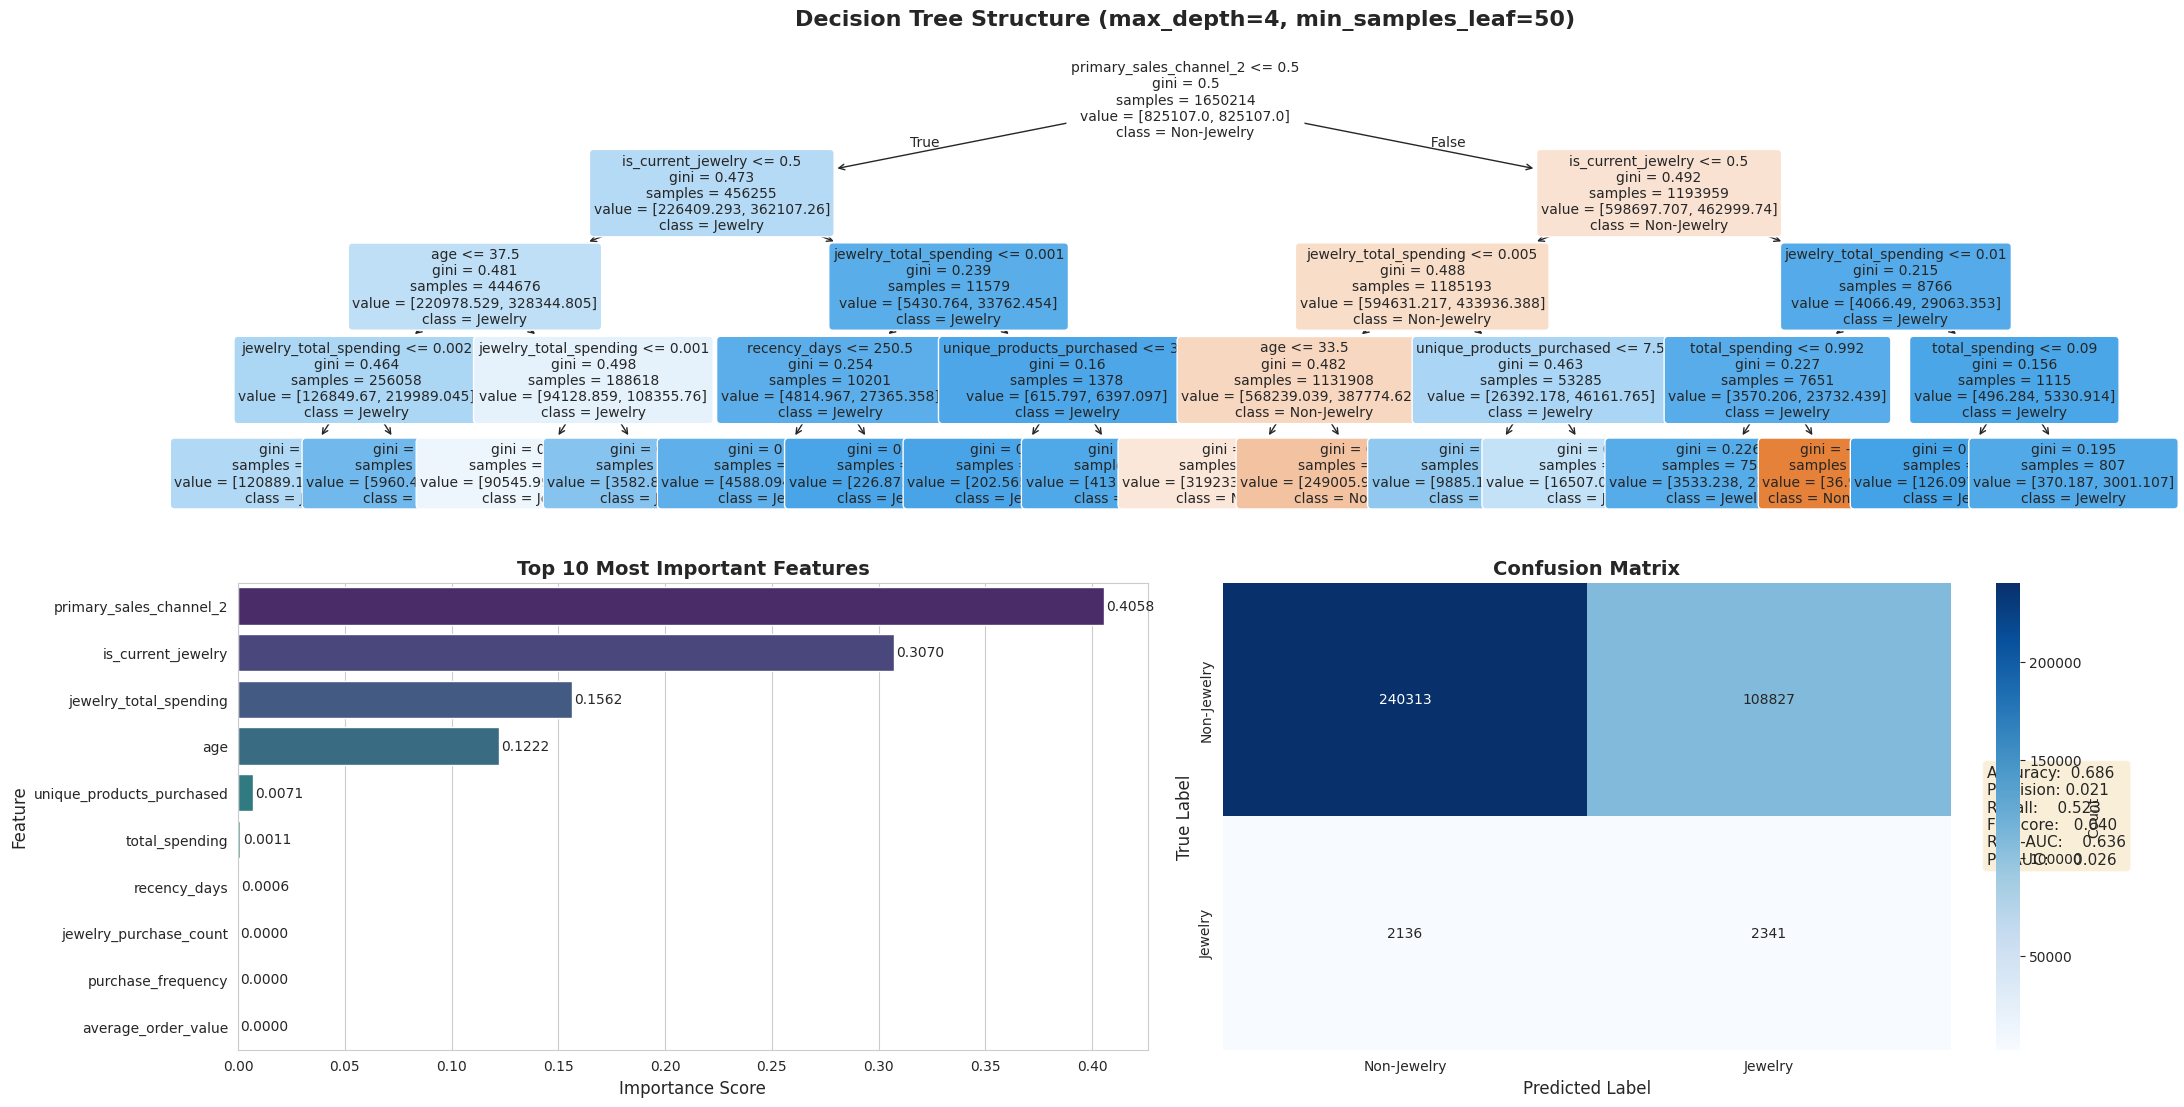

✓ All visualizations generated successfully (baseline feature set)


In [53]:
# Step 3: Decision Tree Visualizations (aligned with baseline 30-feature version) + SAVE FIGURE
# 步驟 3：決策樹視覺化（與你目前的 dt_model / X_train_imp_baseline / tree_metrics 變數一致）+ 存檔

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# ✅ Sanity checks (baseline 30-feature version)
assert hasattr(dt_model, "tree_"), "dt_model not fitted. Please run dt_model.fit(...) first."
assert X_train_imp_baseline.shape[1] == len(dt_model.feature_importances_), "Feature count mismatch."
assert "tree_metrics" in globals(), "tree_metrics not found. Please run the evaluation cell first."

# Ensure output folder exists
results_path = "results"
os.makedirs(results_path, exist_ok=True)
out_path = os.path.join(results_path, "task6_decision_tree_visualizations.png")

# Create figure with subplots
fig = plt.figure(figsize=(22, 16))

# ============================================================
# Chart 1: Decision Tree Structure (shallow, interpretable)
# ============================================================
ax1 = plt.subplot(3, 1, 1)
plot_tree(
    dt_model,
    filled=True,
    rounded=True,
    feature_names=list(X_train_imp_baseline.columns),
    class_names=["Non-Jewelry", "Jewelry"],
    fontsize=10,
    ax=ax1,
)
ax1.set_title(
    "Decision Tree Structure (max_depth=4, min_samples_leaf=50)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# ============================================================
# Chart 2: Feature Importance (Top 10)
# ============================================================
ax2 = plt.subplot(3, 2, 3)

feature_importance = (
    pd.DataFrame({
        "feature": list(X_train_imp_baseline.columns),
        "importance": dt_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

sns.barplot(data=feature_importance, y="feature", x="importance", palette="viridis", ax=ax2)
ax2.set_title("Top 10 Most Important Features", fontsize=14, fontweight="bold")
ax2.set_xlabel("Importance Score", fontsize=12)
ax2.set_ylabel("Feature", fontsize=12)

for i, v in enumerate(feature_importance["importance"].values):
    ax2.text(float(v) + 0.001, i, f"{float(v):.4f}", va="center", fontsize=10)

# ============================================================
# Chart 3: Confusion Matrix (Decision Tree)
# ============================================================
ax3 = plt.subplot(3, 2, 4)
dt_cm = tree_metrics["confusion_matrix"]

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Jewelry", "Jewelry"],
    yticklabels=["Non-Jewelry", "Jewelry"],
    ax=ax3,
    cbar_kws={"label": "Count"},
)
ax3.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
ax3.set_ylabel("True Label", fontsize=12)
ax3.set_xlabel("Predicted Label", fontsize=12)

metrics_text = (
    f"Accuracy:  {tree_metrics['accuracy']:.3f}\n"
    f"Precision: {tree_metrics['precision']:.3f}\n"
    f"Recall:    {tree_metrics['recall']:.3f}\n"
    f"F1-Score:   {tree_metrics['f1']:.3f}\n"
    f"ROC-AUC:    {tree_metrics['roc_auc']:.3f}\n"
    f"PR-AUC:     {tree_metrics['pr_auc']:.3f}"
)
ax3.text(
    1.05, 0.5, metrics_text,
    transform=ax3.transAxes,
    fontsize=11,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()

# Save then show
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"✓ Figure saved to: {out_path}")

plt.show()
print("✓ All visualizations generated successfully (baseline feature set)")

## Step 4: Model Comparison - Baseline vs Advanced (模型比較)

Compare the baseline Logistic Regression with the Decision Tree model to see which performs better.

In [36]:
# Step 4B: Metric-by-metric winner summary (with emoji) using model_results
# 步驟 4B：逐項指標宣告誰贏（含 emoji；資料來源統一用 model_results，避免 baseline_metrics 結構差異）

import numpy as np

# Must have these two keys saved already
lr_key = "logreg_baseline_threshold_0p50"
dt_key = "decision_tree_depth4_leaf50_test_threshold_0p50" # FIX: Use the key for test results

assert "model_results" in globals(), "model_results not found. Please run the append cells first."
assert lr_key in model_results, f"Missing {lr_key} in model_results."
assert dt_key in model_results, f"Missing {dt_key} in model_results."

lr = model_results[lr_key]
dt = model_results[dt_key]

metrics_to_compare = ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]

print("\n" + "=" * 90)
print("📊 METRIC-BY-METRIC COMPARISON: Logistic Regression vs Decision Tree")
print("=" * 90)

dt_wins = 0
lr_wins = 0
ties = 0

for m in metrics_to_compare:
    lr_val = lr.get(m, None)
    dt_val = dt.get(m, None)

    # Handle missing values gracefully
    if lr_val is None or dt_val is None or (isinstance(lr_val, float) and np.isnan(lr_val)) or (isinstance(dt_val, float) and np.isnan(dt_val)):
        print(f"  {m:10s}: ⚠️ Missing value(s) → LR={lr_val}, DT={dt_val}")
        continue

    diff = float(dt_val) - float(lr_val)
    if diff > 0:
        winner = "🏆 Decision Tree"
        dt_wins += 1
    elif diff < 0:
        winner = "🏆 Logistic Regression"
        lr_wins += 1
    else:
        winner = "🤝 Tie"
        ties += 1

    print(f"  {m:10s}: LR={lr_val:.4f}, DT={dt_val:.4f}, Δ={diff:+.4f} → {winner}")

print("\n" + "=" * 90)
print("🧾 EXECUTIVE SUMMARY (Quick Takeaway)")
print("=" * 90)

total_compared = dt_wins + lr_wins + ties
print(f"Compared metrics: {total_compared} (DT wins={dt_wins}, LR wins={lr_wins}, ties={ties})")

if dt_wins > lr_wins:
    print("✅ RECOMMENDATION: 🏆 Decision Tree performs better overall on the selected metrics.")
    print("   💡 Added benefit: Rule-based logic is easier to communicate and visualize for executives.")
elif lr_wins > dt_wins:
    print("✅ RECOMMENDATION: 🏆 Logistic Regression performs better overall on the selected metrics.")
    print("   💡 Added benefit: Strong baseline, stable, and often generalizes well with fewer assumptions.")
else:
    print("🤝 RECOMMENDATION: Overall performance is similar.")
    print("   💡 Use Decision Tree for interpretability; use Logistic Regression as a robust baseline.")
print("=" * 90)



📊 METRIC-BY-METRIC COMPARISON: Logistic Regression vs Decision Tree
  roc_auc   : LR=0.6563, DT=0.6406, Δ=-0.0157 → 🏆 Logistic Regression
  pr_auc    : LR=0.0296, DT=0.0259, Δ=-0.0037 → 🏆 Logistic Regression
  accuracy  : LR=0.6885, DT=0.6854, Δ=-0.0031 → 🏆 Logistic Regression
  precision : LR=0.0219, DT=0.0213, Δ=-0.0006 → 🏆 Logistic Regression
  recall    : LR=0.5409, DT=0.5317, Δ=-0.0092 → 🏆 Logistic Regression
  f1        : LR=0.0421, DT=0.0410, Δ=-0.0011 → 🏆 Logistic Regression

🧾 EXECUTIVE SUMMARY (Quick Takeaway)
Compared metrics: 6 (DT wins=0, LR wins=6, ties=0)
✅ RECOMMENDATION: 🏆 Logistic Regression performs better overall on the selected metrics.
   💡 Added benefit: Strong baseline, stable, and often generalizes well with fewer assumptions.


In [54]:
# Step 4B  an automatic MIN_SAMPLES suggestion
# Step 4B：自動建議一個合理的 MIN_SAMPLES（避免太嚴格選不到 leaf）

import numpy as np
import pandas as pd
from sklearn.tree import _tree

# --- FIX: Generate df_rules from the dt_model before using it ---

def tree_to_rules_df(tree, feature_names, X_train, y_train):
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]

    # Dictionary to store rule data
    rules_data = []

    def recurse(node, depth, parent_path, is_left):
        impurity = tree_.impurity[node]
        n_samples = tree_.n_node_samples[node]
        value = tree_.value[node][0] # [n_samples_class_0, n_samples_class_1]
        n_positive = value[1] # n_samples for class 1 (jewelry)

        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            if is_left:
                path = f"{parent_path} (X['{name}'] <= {threshold:.2f})"
            else:
                path = f"{parent_path} (X['{name}'] > {threshold:.2f})"

            recurse(tree_.children_left[node], depth + 1, path, True)
            recurse(tree_.children_right[node], depth + 1, path, False)
        else: # Leaf node
            # Map leaf node to original training samples to get exact counts
            # This mapping requires knowing which training samples ended up in which leaf node.
            # A simpler approach is to use the n_node_samples and value from tree_ for the leaf.

            # Calculate jewelry rate for this leaf
            jewelry_rate = n_positive / n_samples if n_samples > 0 else 0

            rules_data.append({
                'leaf_node': node,
                'rule': parent_path.strip(), # Clean up the path string
                'n_samples_train': n_samples,
                'n_positive_train': n_positive,
                'jewelry_rate_train': jewelry_rate
            })

    # Start recursion from root node
    # Initial call starts with a dummy path and sets the first condition
    if tree_.feature[0] != _tree.TREE_UNDEFINED:
        name = feature_name[0]
        threshold = tree_.threshold[0]

        # Left child path
        recurse(tree_.children_left[0], 1, f" (X['{name}'] <= {threshold:.2f})", True)
        # Right child path
        recurse(tree_.children_right[0], 1, f" (X['{name}'] > {threshold:.2f})", False)
    else: # If root is a leaf (trivial tree)
        jewelry_rate = tree_.value[0][0][1] / tree_.n_node_samples[0] if tree_.n_node_samples[0] > 0 else 0
        rules_data.append({
            'leaf_node': 0,
            'rule': 'Root is leaf',
            'n_samples_train': tree_.n_node_samples[0],
            'n_positive_train': tree_.value[0][0][1],
            'jewelry_rate_train': jewelry_rate
        })

    return pd.DataFrame(rules_data)

# Assuming dt_model is your trained DecisionTreeClassifier
# Assuming X_train_imp_baseline is your preprocessed training features
# Assuming y_train_baseline is your training labels

df_rules = tree_to_rules_df(dt_model, X_train_imp_baseline.columns, X_train_imp_baseline, y_train_baseline)

# --- End of FIX ---

# Show leaf sample-size distribution to pick a sensible cutoff
print("=" * 90)
print("Leaf sample size distribution (TRAIN set)")
print("=" * 90)
print(df_rules["n_samples_train"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_string())
print("\nTop 10 largest leaves:")
print(df_rules.sort_values("n_samples_train", ascending=False).head(10)[
    ["leaf_node", "n_samples_train", "n_positive_train", "jewelry_rate_train", "rule"]
].to_string(index=False))
print("=" * 90)

# Auto-pick MIN_SAMPLES as the 90th percentile leaf size (at least 200)
suggested = int(max(200, df_rules["n_samples_train"].quantile(0.90)))
print(f"Suggested MIN_SAMPLES (90th percentile, min 200): {suggested}")

# Now pick top rules with the suggested threshold
MIN_SAMPLES = suggested

df_candidates = df_rules[df_rules["n_samples_train"] >= MIN_SAMPLES].copy()
top3 = (
    df_candidates
    .sort_values(["jewelry_rate_train", "n_samples_train"], ascending=[False, False])
    .head(3)
    .copy()
)

top3["jewelry_rate_train_pct"] = (top3["jewelry_rate_train"] * 100).round(2).astype(str) + "%"
top3 = top3[[
    "rule",
    "n_samples_train",
    "n_positive_train",
    "jewelry_rate_train_pct",
    "leaf_node",
]]

print("\n" + "=" * 90)
print("TOP 3 HIGH-JEWELRY-RATE RULES (from TRAIN set leaves)")
print(f"(Filtered by n_samples_train >= {MIN_SAMPLES})")
print("=" * 90)
print(top3.to_string(index=False))
print("=" * 90)

top_decision_rules = top3


Leaf sample size distribution (TRAIN set)
count        16.000000
mean     103138.375000
std      195725.735562
min          73.000000
50%        8630.000000
75%       70222.000000
90%      369383.500000
95%      530482.000000
99%      615614.800000
max      636898.000000

Top 10 largest leaves:
 leaf_node  n_samples_train  n_positive_train  jewelry_rate_train                                                                                                                                                 rule
        19           636898          0.446294        7.007300e-07                     (X['primary_sales_channel_2'] > 0.50) (X['is_current_jewelry'] > 0.50) (X['jewelry_total_spending'] <= 0.01) (X['age'] <= 33.50)
        20           495010          0.343815        6.945615e-07                     (X['primary_sales_channel_2'] > 0.50) (X['is_current_jewelry'] > 0.50) (X['jewelry_total_spending'] <= 0.01) (X['age'] <= 33.50)
         4           243757          0.622115        2.5521

# Task 6: Additional Advanced Models - Random Forest & Neural Network
## 任務 6: 額外進階模型 - 隨機森林與神經網絡

We now build two additional state-of-the-art models:
1. **Random Forest** - Ensemble method with feature importance
2. **Neural Network (MLP)** - Deep learning approach with surrogate explanation

Both will follow the same evaluation structure as the baseline and decision tree models.


## Step 1: Train Random Forest Model
### 隨機森林模型訓練

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.


In [38]:

# Task 6 (Updated): Random Forest using shared folds
# 任務 6（更新版）：使用共用 folds 的隨機森林

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import pandas as pd

print('\n' + '='*70)
print('STEP 1-2: RANDOM FOREST (shared train / val / test folds)')
print('步驟 1-2：Random Forest（共用 train / val / test 切分）')
print('='*70)

def compute_binary_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

# ------------------------------------------------------------
# A) Train on TRAIN only, evaluate on VAL
# ------------------------------------------------------------
X_train_for_rf = X_train_imp_baseline
y_train_for_rf = y_train_baseline
X_val_for_rf = X_val_imp_baseline
y_val_for_rf = y_val_baseline

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

rf_model.fit(X_train_for_rf, y_train_for_rf)
print(f'✓ Random Forest trained on train fold: {rf_model.n_estimators} trees')

y_pred_rf = rf_model.predict(X_val_for_rf)
y_proba_rf = rf_model.predict_proba(X_val_for_rf)[:, 1]
rf_metrics = compute_binary_metrics(y_val_for_rf, y_pred_rf, y_proba_rf)

print('\n[Validation] Random Forest')
for k, v in rf_metrics.items():
    if k != "confusion_matrix":
        print(f'  - {k}: {v:.4f}')
print('  - confusion_matrix:')
print(rf_metrics["confusion_matrix"])

# ------------------------------------------------------------
# B) Refit on TRAIN+VAL, then evaluate on TEST
# ------------------------------------------------------------
X_train_val_imp_baseline = pd.concat([X_train_imp_baseline, X_val_imp_baseline], axis=0)
y_train_val_baseline = pd.concat([y_train_baseline, y_val_baseline], axis=0)

rf_model_test = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf_model_test.fit(X_train_val_imp_baseline, y_train_val_baseline)

y_pred_rf_test = rf_model_test.predict(X_test_imp_baseline)
y_proba_rf_test = rf_model_test.predict_proba(X_test_imp_baseline)[:, 1]
rf_test_metrics = compute_binary_metrics(y_test_baseline, y_pred_rf_test, y_proba_rf_test)

print('\n[Test after refit on Train+Val] Random Forest')
for k, v in rf_test_metrics.items():
    if k != "confusion_matrix":
        print(f'  - {k}: {v:.4f}')
print('  - confusion_matrix:')
print(rf_test_metrics["confusion_matrix"])

if "model_results" not in globals():
    model_results = {}

model_results["random_forest_depth20_leaf50_n200_val_threshold_0p50"] = {
    "split": "validation",
    "model_name": "Random Forest (balanced), n_estimators=200, max_depth=20, min_samples_leaf=50, threshold=0.50",
    "n_features": int(getattr(rf_model, "n_features_in_", X_train_for_rf.shape[1])),
    "threshold": 0.50,
    "roc_auc": float(rf_metrics["roc_auc"]),
    "pr_auc": float(rf_metrics["pr_auc"]),
    "accuracy": float(rf_metrics["accuracy"]),
    "precision": float(rf_metrics["precision"]),
    "recall": float(rf_metrics["recall"]),
    "f1": float(rf_metrics["f1"]),
    "confusion_matrix": rf_metrics["confusion_matrix"],
}

model_results["random_forest_depth20_leaf50_n200_test_threshold_0p50"] = {
    "split": "test",
    "model_name": "Random Forest refit on train+val, n_estimators=200, max_depth=20, min_samples_leaf=50, threshold=0.50",
    "n_features": int(getattr(rf_model_test, "n_features_in_", X_train_val_imp_baseline.shape[1])),
    "threshold": 0.50,
    "roc_auc": float(rf_test_metrics["roc_auc"]),
    "pr_auc": float(rf_test_metrics["pr_auc"]),
    "accuracy": float(rf_test_metrics["accuracy"]),
    "precision": float(rf_test_metrics["precision"]),
    "recall": float(rf_test_metrics["recall"]),
    "f1": float(rf_test_metrics["f1"]),
    "confusion_matrix": rf_test_metrics["confusion_matrix"],
}

print("\n✓ Saved random forest validation + test results into model_results")



STEP 1-2: RANDOM FOREST (shared train / val / test folds)
步驟 1-2：Random Forest（共用 train / val / test 切分）
✓ Random Forest trained on train fold: 200 trees

[Validation] Random Forest
  - accuracy: 0.7907
  - precision: 0.0240
  - recall: 0.3909
  - f1: 0.0451
  - roc_auc: 0.6368
  - pr_auc: 0.0286
  - confusion_matrix:
[[277844  71296]
 [  2727   1750]]

[Test after refit on Train+Val] Random Forest
  - accuracy: 0.7877
  - precision: 0.0239
  - recall: 0.3955
  - f1: 0.0451
  - roc_auc: 0.6357
  - pr_auc: 0.0284
  - confusion_matrix:
[[276780  72360]
 [  2707   1771]]

✓ Saved random forest validation + test results into model_results


In [39]:
# Step 2B (Recommended): Random Forest Threshold Sweep on VALIDATION set (0.01 step, 101 thresholds)
# 步驟 2B（推薦）：在驗證集上進行 Random Forest 閾值掃描（每 0.01，一共 101 個 threshold）
#
# Prereq:
# - You already trained rf_model on train fold
# - You already computed y_proba_rf on the VALIDATION set (y_val_baseline)
#   e.g., y_proba_rf = rf_model.predict_proba(X_val_for_rf)[:, 1]

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Sanity checks
assert "y_val_baseline" in globals(), "y_val_baseline not found."
assert "y_proba_rf" in globals(), "y_proba_rf not found. Please compute it first (rf_model on val set)."
assert len(y_val_baseline) == len(y_proba_rf), "y_val_baseline and y_proba_rf length mismatch."

y_true = y_val_baseline
proba = y_proba_rf  # Validation probabilities from rf_model (trained on train only)

thresholds = np.round(np.linspace(0.00, 1.00, 101), 2)

rows = []
for t in thresholds:
    y_pred = (proba >= t).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    rows.append({
        "threshold": float(t),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "predicted_positives": int(tp + fp),
    })

rf_sweep_df = pd.DataFrame(rows).sort_values("threshold")

# 1) Best F1 threshold
best_f1_row = rf_sweep_df.loc[rf_sweep_df["f1"].idxmax()]

print("=" * 90)
print("RANDOM FOREST THRESHOLD SWEEP ON VALIDATION SET (step=0.01)")
print("=" * 90)
print(f"Best F1 threshold: {best_f1_row['threshold']:.2f}")
print(f"  Precision={best_f1_row['precision']:.4f} | Recall={best_f1_row['recall']:.4f} | F1={best_f1_row['f1']:.4f}")
print(f"  TP={int(best_f1_row['tp'])} FP={int(best_f1_row['fp'])} FN={int(best_f1_row['fn'])} TN={int(best_f1_row['tn'])}")
print(f"  Predicted positives={int(best_f1_row['predicted_positives'])}")
print("=" * 90)

# 2) Precision constraint view (good for marketing list quality)
for target_p in [0.05, 0.10]:
    eligible = rf_sweep_df[rf_sweep_df["precision"] >= target_p].copy()
    if len(eligible) == 0:
        print(f"⚠️ No threshold achieves precision ≥ {target_p:.0%}.")
        continue
    best_row = eligible.sort_values(["recall", "f1"], ascending=False).iloc[0]
    print(f"🎯 Best Recall with Precision ≥ {target_p:.0%}: threshold={best_row['threshold']:.2f}")
    print(f"  Precision={best_row['precision']:.4f} | Recall={best_row['recall']:.4f} | F1={best_row['f1']:.4f}")
    print(f"  Predicted positives={int(best_row['predicted_positives'])} | TP={int(best_row['tp'])} | FP={int(best_row['fp'])}")

print("\nTop 10 thresholds by F1:")
print(rf_sweep_df.sort_values("f1", ascending=False).head(10)[
    ["threshold", "precision", "recall", "f1", "predicted_positives", "tp", "fp"]
].to_string(index=False))

# Optional: save best-threshold results into model_results (so it appears in your comparison table)
if "model_results" not in globals():
    model_results = {}

best_t = float(best_f1_row["threshold"])
best_pred = (proba >= best_t).astype(int)

# recompute at best threshold (for safety)
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

model_results[f"random_forest_val_best_f1_threshold_{best_t:.2f}"] = {
    "model_name": f"Random Forest (balanced) val-tuned threshold (best F1 @ {best_t:.2f})",
    "split": "validation",
    "n_features": int(getattr(rf_model, "n_features_in_", X_val_imp_baseline.shape[1])),
    "threshold": best_t,
    "roc_auc": float(model_results["random_forest_depth20_leaf50_n200_val_threshold_0p50"]["roc_auc"]) if "random_forest_depth20_leaf50_n200_val_threshold_0p50" in model_results else None,
    "pr_auc": float(model_results["random_forest_depth20_leaf50_n200_val_threshold_0p50"]["pr_auc"]) if "random_forest_depth20_leaf50_n200_val_threshold_0p50" in model_results else None,
    "accuracy": float(accuracy_score(y_true, best_pred)),
    "precision": float(precision_score(y_true, best_pred, zero_division=0)),
    "recall": float(recall_score(y_true, best_pred, zero_division=0)),
    "f1": float(f1_score(y_true, best_pred, zero_division=0)),
    "confusion_matrix": confusion_matrix(y_true, best_pred),
}

print(f"\n✓ Saved tuned RF (val sweep) result into model_results['random_forest_val_best_f1_threshold_{best_t:.2f}']")
print("Current models saved:", list(model_results.keys()))


RANDOM FOREST THRESHOLD SWEEP ON VALIDATION SET (step=0.01)
Best F1 threshold: 0.70
  Precision=0.0773 | Recall=0.0742 | F1=0.0757
  TP=332 FP=3965 FN=4145 TN=345175
  Predicted positives=4297
🎯 Best Recall with Precision ≥ 5%: threshold=0.67
  Precision=0.0562 | Recall=0.0956 | F1=0.0708
  Predicted positives=7613 | TP=428 | FP=7185
🎯 Best Recall with Precision ≥ 10%: threshold=0.85
  Precision=0.1070 | Recall=0.0071 | F1=0.0134
  Predicted positives=299 | TP=32 | FP=267

Top 10 thresholds by F1:
 threshold  precision   recall       f1  predicted_positives  tp   fp
      0.70   0.077263 0.074157 0.075678                 4297 332 3965
      0.69   0.073748 0.076614 0.075153                 4651 343 4308
      0.71   0.079410 0.068573 0.073595                 3866 307 3559
      0.72   0.082649 0.065222 0.072909                 3533 292 3241
      0.73   0.086762 0.060755 0.071466                 3135 272 2863
      0.68   0.062354 0.083538 0.071408                 5998 374 5624
      0

In [40]:
# Append: Random Forest tuned for Precision ≥ 5% (best recall) into model_results
# 補存：Random Forest（Precision ≥ 5% 時 Recall 最佳的門擛）到 model_results，方便統一比較

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

assert "rf_sweep_df" in globals(), "rf_sweep_df not found. Please run the RF threshold sweep cell first."
assert "y_proba_rf_test" in globals(), "y_proba_rf_test not found. Please compute it first."
assert "y_test_baseline" in globals(), "y_test_baseline not found."

target_p = 0.05
eligible = rf_sweep_df[rf_sweep_df["precision"] >= target_p].copy()
assert len(eligible) > 0, "No threshold achieves precision ≥ 5%."

best_p05 = eligible.sort_values(["recall", "f1"], ascending=False).iloc[0]
t_p05 = float(best_p05["threshold"])

y_true = y_test_baseline
proba = y_proba_rf_test # FIX: Use y_proba_rf_test instead of y_proba_rf
y_pred_p05 = (proba >= t_p05).astype(int)

if "model_results" not in globals():
    model_results = {}

model_results[f"random_forest_precision_ge_0p05_best_recall_threshold_{t_p05:.2f}"] = {
    "model_name": f"Random Forest (balanced) tuned threshold (Precision ≥ 5%, best Recall @ {t_p05:.2f})",
    "n_features": int(getattr(rf_model, "n_features_in_", X_test_imp_baseline.shape[1])),
    "threshold": t_p05,
    # ROC/PR AUC are threshold-independent: reuse the RF scores you already stored
    "roc_auc": float(model_results["random_forest_depth20_leaf50_n200_test_threshold_0p50"]["roc_auc"]) if "random_forest_depth20_leaf50_n200_test_threshold_0p50" in model_results else None,
    "pr_auc": float(model_results["random_forest_depth20_leaf50_n200_test_threshold_0p50"]["pr_auc"]) if "random_forest_depth20_leaf50_n200_test_threshold_0p50" in model_results else None,
    "accuracy": float(accuracy_score(y_true, y_pred_p05)),
    "precision": float(precision_score(y_true, y_pred_p05, zero_division=0)),
    "recall": float(recall_score(y_true, y_pred_p05, zero_division=0)),
    "f1": float(f1_score(y_true, y_pred_p05, zero_division=0)),
    "confusion_matrix": confusion_matrix(y_true, y_pred_p05),
    "predicted_positives": int(best_p05["predicted_positives"]),
    "tp": int(best_p05["tp"]),
    "fp": int(best_p05["fp"]),
    "fn": int(best_p05["fn"]),
    "tn": int(best_p05["tn"]),
}

print(f"\n✓ Saved tuned RF (Precision ≥ 5%, best Recall) into model_results at threshold={t_p05:.2f}")
print("Key:", f"random_forest_precision_ge_0p05_best_recall_threshold_{t_p05:.2f}")
print("Current models saved:", list(model_results.keys()))



✓ Saved tuned RF (Precision ≥ 5%, best Recall) into model_results at threshold=0.67
Key: random_forest_precision_ge_0p05_best_recall_threshold_0.67
Current models saved: ['logreg_baseline_threshold_0p50', 'decision_tree_depth4_leaf50_val_threshold_0p50', 'decision_tree_depth4_leaf50_test_threshold_0p50', 'random_forest_depth20_leaf50_n200_val_threshold_0p50', 'random_forest_depth20_leaf50_n200_test_threshold_0p50', 'random_forest_val_best_f1_threshold_0.70', 'random_forest_precision_ge_0p05_best_recall_threshold_0.67']


## Step 2: Random Forest Visualizations
### 隨機森林可視化

Display one representative tree, feature importance, and confusion matrix.


✓ Figure saved to: results/task7_random_forest_visualizations_tuned_p05_readable_tree.png


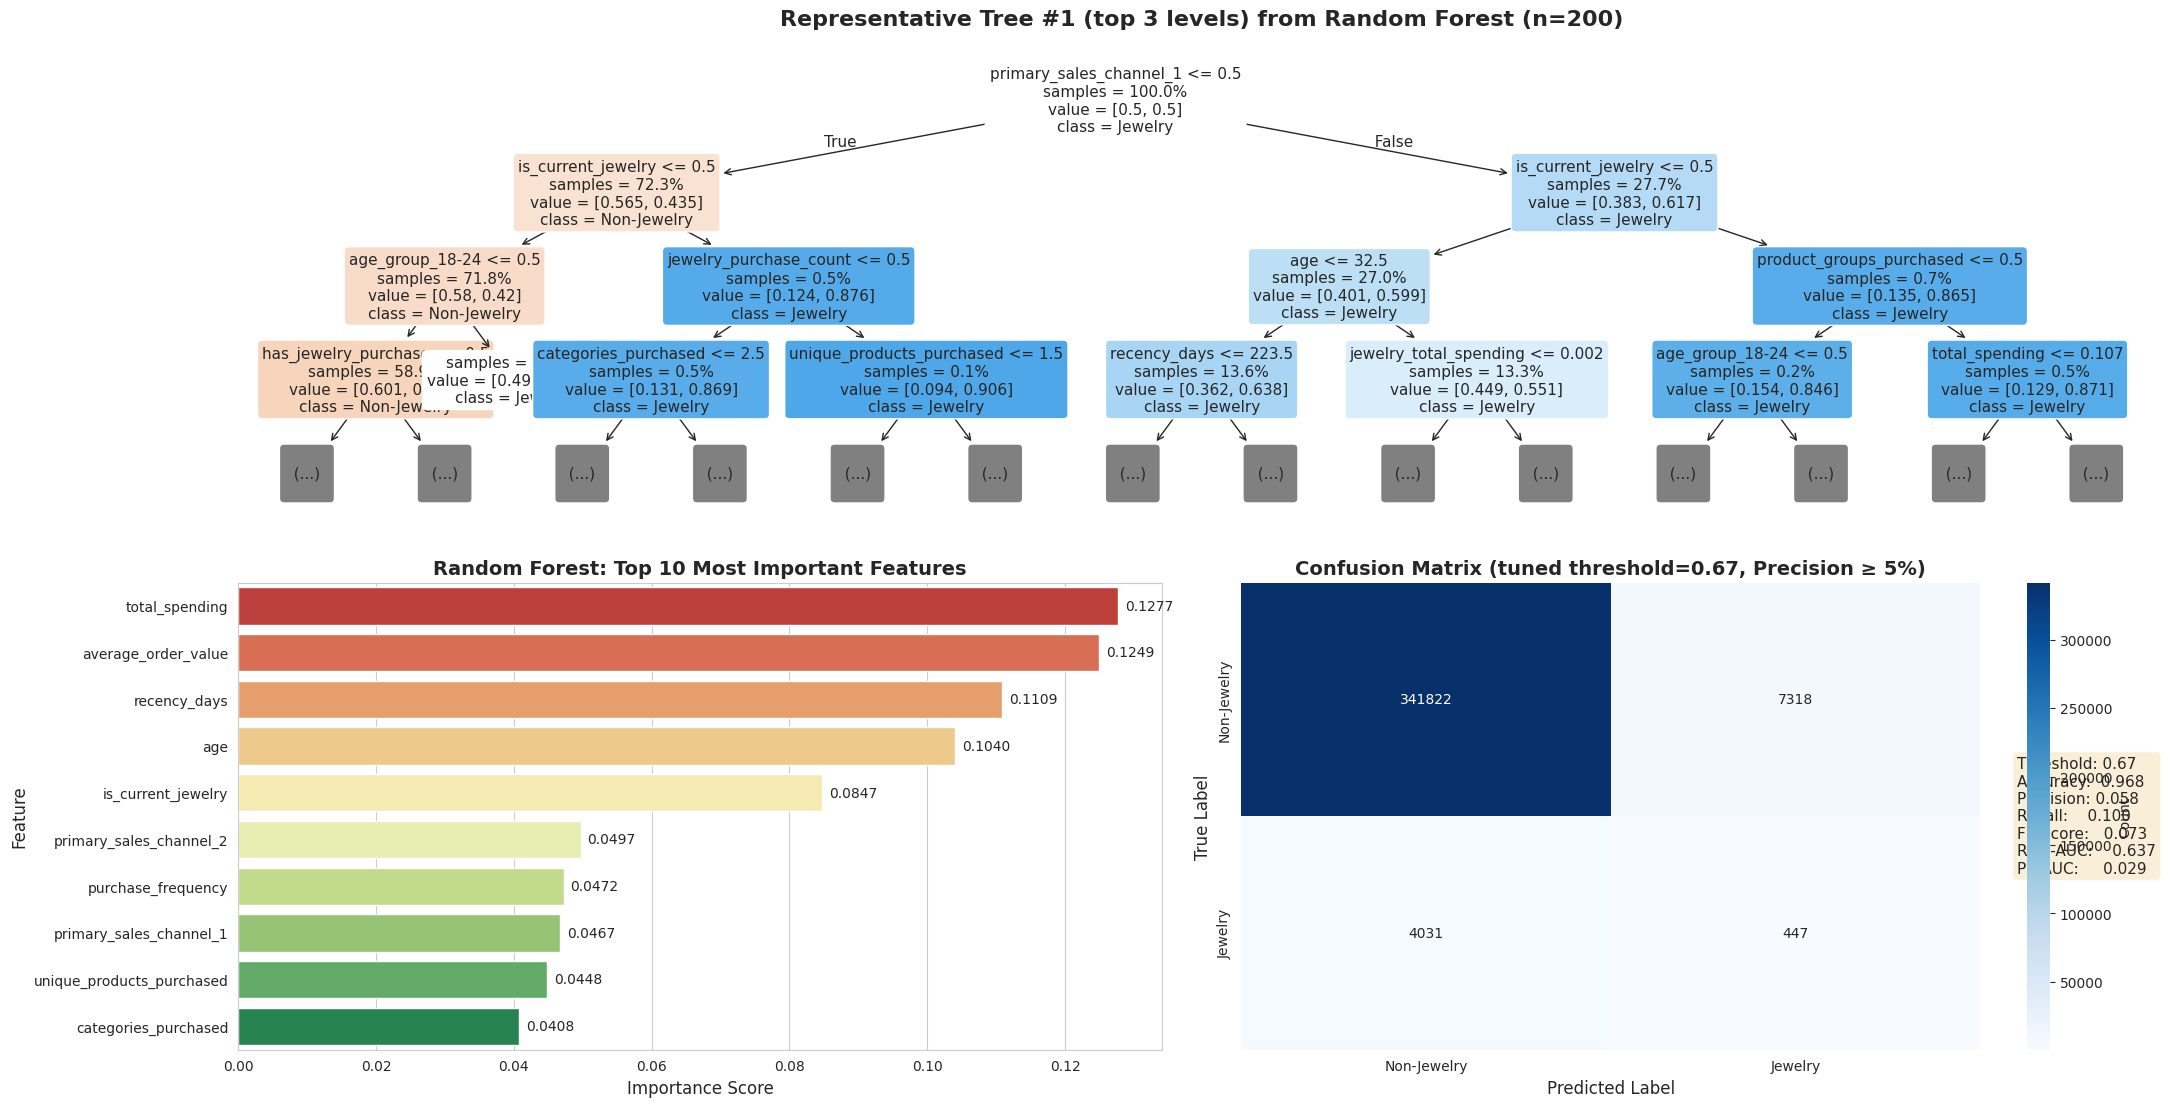

✓ RF visualizations generated (readable tree: top 3 levels, tuned threshold=0.67)


In [41]:
# Step 3 (RF) - FIX: Make the representative tree readable (plot only top levels) + keep tuned CM + SAVE
# 修正：RF 樹太擁 → 只畫前幾層（max_depth_to_plot），其餘保留（Top10 importance + tuned CM）

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ✅ Sanity checks
assert "rf_model" in globals(), "rf_model not found. Please train the Random Forest first."
assert hasattr(rf_model, "estimators_"), "rf_model has no estimators_. Did training finish?"
assert "rf_metrics" in globals(), "rf_metrics not found. Please run the RF evaluation cell first."
assert hasattr(X_train_imp_baseline, "columns"), "X_train_imp_baseline must be a DataFrame for feature names."
assert "rf_sweep_df" in globals(), "rf_sweep_df not found. Please run the RF threshold sweep cell first."
assert "y_proba_rf_test" in globals(), "y_proba_rf_test not found."
assert "y_test_baseline" in globals(), "y_test_baseline not found."

# ------------------------------------------------------------
# Tuned threshold: Precision ≥ 5% with best recall
# ------------------------------------------------------------
target_p = 0.05
eligible = rf_sweep_df[rf_sweep_df["precision"] >= target_p].copy()
assert len(eligible) > 0, "No threshold achieves precision ≥ 5%."

best_p05 = eligible.sort_values(["recall", "f1"], ascending=False).iloc[0]
t_p05 = float(best_p05["threshold"])

y_true = y_test_baseline
proba = y_proba_rf_test # FIX: Use y_proba_rf_test for test probabilities
y_pred_tuned = (proba >= t_p05).astype(int)

rf_cm_tuned = confusion_matrix(y_true, y_pred_tuned)
rf_acc_tuned = float(accuracy_score(y_true, y_pred_tuned))
rf_prec_tuned = float(precision_score(y_true, y_pred_tuned, zero_division=0))
rf_rec_tuned = float(recall_score(y_true, y_pred_tuned, zero_division=0))
rf_f1_tuned = float(f1_score(y_true, y_pred_tuned, zero_division=0))

# ------------------------------------------------------------
# Output path
# ------------------------------------------------------------
results_path = "results"
os.makedirs(results_path, exist_ok=True)
out_path = os.path.join(results_path, "task7_random_forest_visualizations_tuned_p05_readable_tree.png")

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(22, 16))

# ============================================================
# Chart 1: Representative Tree (ONLY top levels to be readable)
# ============================================================
ax1 = plt.subplot(3, 1, 1)

estimator = rf_model.estimators_[0]
max_depth_to_plot = 3  # ✅ change to 2~4 depending on readability

plot_tree(
    estimator,
    filled=True,
    rounded=True,
    feature_names=list(X_train_imp_baseline.columns),
    class_names=["Non-Jewelry", "Jewelry"],
    fontsize=11,
    max_depth=max_depth_to_plot,
    impurity=False,          # reduce clutter
    proportion=True,         # show proportions instead of raw counts (cleaner)
    ax=ax1,
)
ax1.set_title(
    f"Representative Tree #1 (top {max_depth_to_plot} levels) from Random Forest (n={rf_model.n_estimators})",
    fontsize=16, fontweight="bold", pad=20
)

# ============================================================
# Chart 2: Feature Importance (Top 10)
# ============================================================
ax2 = plt.subplot(3, 2, 3)

feature_importance_rf = (
    pd.DataFrame({
        "feature": list(X_train_imp_baseline.columns),
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

sns.barplot(data=feature_importance_rf, y="feature", x="importance", palette="RdYlGn", ax=ax2)
ax2.set_title("Random Forest: Top 10 Most Important Features", fontsize=14, fontweight="bold")
ax2.set_xlabel("Importance Score", fontsize=12)
ax2.set_ylabel("Feature", fontsize=12)

for i, v in enumerate(feature_importance_rf["importance"].values):
    ax2.text(float(v) + 0.001, i, f"{float(v):.4f}", va="center", fontsize=10)

# ============================================================
# Chart 3: Confusion Matrix (TUNED threshold: Precision ≥ 5%)
# ============================================================
ax3 = plt.subplot(3, 2, 4)

sns.heatmap(
    rf_cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Jewelry", "Jewelry"],
    yticklabels=["Non-Jewelry", "Jewelry"],
    ax=ax3,
    cbar_kws={"label": "Count"},
)
ax3.set_title(f"Confusion Matrix (tuned threshold={t_p05:.2f}, Precision ≥ 5%)",
              fontsize=14, fontweight="bold")
ax3.set_ylabel("True Label", fontsize=12)
ax3.set_xlabel("Predicted Label", fontsize=12)

metrics_text = (
    f"Threshold: {t_p05:.2f}\n"
    f"Accuracy:  {rf_acc_tuned:.3f}\n"
    f"Precision: {rf_prec_tuned:.3f}\n"
    f"Recall:    {rf_rec_tuned:.3f}\n"
    f"F1-Score:   {rf_f1_tuned:.3f}\n"
    f"ROC-AUC:    {rf_metrics.get('roc_auc', float('nan')):.3f}\n"
    f"PR-AUC:     {rf_metrics.get('pr_auc', float('nan')):.3f}"
)
ax3.text(
    1.05, 0.5, metrics_text,
    transform=ax3.transAxes,
    fontsize=11,
    verticalalignment="center",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"✓ Figure saved to: {out_path}")
plt.show()

print(f"✓ RF visualizations generated (readable tree: top {max_depth_to_plot} levels, tuned threshold={t_p05:.2f})")


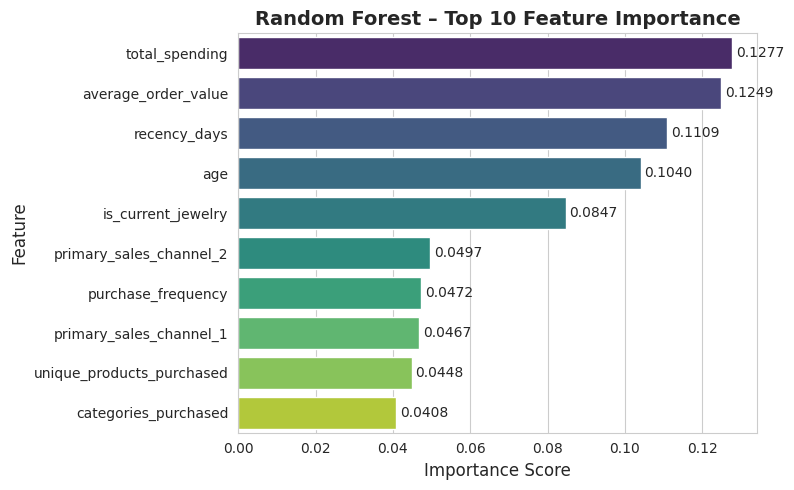

✓ Saved: rf_feature_importance.png


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rf_feature_importance = (
    pd.DataFrame({
        "feature": list(X_train_imp_baseline.columns),
        "importance": rf_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rf_feature_importance, y="feature", x="importance", palette="viridis", ax=ax)
ax.set_title("Random Forest – Top 10 Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
for i, v in enumerate(rf_feature_importance["importance"].values):
    ax.text(float(v) + 0.001, i, f"{float(v):.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: rf_feature_importance.png")

## Neural Network (MLP) Tuning with Stratified 70/15/15 Split
Append-only section to tune an MLP on the transaction-level dataset, using a stratified 70/15/15 split, a 20-trial randomized search (ROC-AUC), and comparison against existing non-NN models on the validation set. Final NN is retrained on train+validation and evaluated once on the held-out test set.

In [43]:

# =========================
# Cell A: MLP Setup using the SAME shared train / val / test indices
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("CELL A: MLP SETUP (SAME SHARED SPLITS -> IMPUTE -> SCALE -> WEIGHTS)")
print("=" * 70)

TARGET_COL = "target_jewelry_purchase"
assert "ml_dataset" in globals(), "ml_dataset not found."
assert "shared_split_idx" in globals(), "shared_split_idx not found. Run the shared split cell first."
assert TARGET_COL in ml_dataset.columns, f"Target column '{TARGET_COL}' not found in ml_dataset."

feature_cols = [c for c in ml_dataset.columns if c != TARGET_COL]
X_full = ml_dataset[feature_cols].copy()
y_full = ml_dataset[TARGET_COL].astype(int)

for drop_col in ["customer_id", "transaction_date"]:
    if drop_col in X_full.columns:
        X_full = X_full.drop(columns=drop_col)

cat_cols = [c for c in ["club_member_status", "fashion_news_frequency", "age_group", "primary_sales_channel"] if c in X_full.columns]
X_encoded = pd.get_dummies(X_full, columns=cat_cols, dummy_na=True, dtype=int)

train_idx = shared_split_idx["train_idx"]
val_idx = shared_split_idx["val_idx"]
test_idx = shared_split_idx["test_idx"]

X_train_raw = X_encoded.loc[train_idx].copy()
X_val_raw = X_encoded.loc[val_idx].copy()
X_test_raw = X_encoded.loc[test_idx].copy()

y_train = y_full.loc[train_idx].copy()
y_val = y_full.loc[val_idx].copy()
y_test = y_full.loc[test_idx].copy()

print(f"Shared split sizes → Train: {len(X_train_raw):,}, Val: {len(X_val_raw):,}, Test: {len(X_test_raw):,}")
print(f"Jewelry rate → Train: {y_train.mean():.4%}, Val: {y_val.mean():.4%}, Test: {y_test.mean():.4%}")
print(f"One-hot feature count → {X_train_raw.shape[1]:,}")

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

X_train = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
X_val = pd.DataFrame(scaler.transform(X_val_imp), columns=X_val_imp.columns, index=X_val_imp.index)
X_test = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns, index=X_test_imp.index)

classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train))
cw = {int(cls): float(w) for cls, w in zip(classes, class_weights)}

y_train_arr = np.asarray(y_train, dtype=int)
sample_weight_train = np.where(y_train_arr == 1, cw[1], cw[0])

print("✓ MLP preprocessing done with the SAME shared folds.")
print("Shapes (scaled):")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")



CELL A: MLP SETUP (SAME SHARED SPLITS -> IMPUTE -> SCALE -> WEIGHTS)
Shared split sizes → Train: 1,650,214, Val: 353,617, Test: 353,618
Jewelry rate → Train: 1.2662%, Val: 1.2661%, Test: 1.2663%
One-hot feature count → 33
✓ MLP preprocessing done with the SAME shared folds.
Shapes (scaled):
  X_train: (1650214, 33), y_train: (1650214,)
  X_val:   (353617, 33), y_val:   (353617,)
  X_test:  (353618, 33), y_test:  (353618,)


In [44]:
# =========================
# 警告 非常花時間的cell
# AVOID RUNNING THIS IF YOU WANT TO NOT DO NUEURAL NETWORK HYPERPARAMETER SEARCH
# Cell B: MLP Hyperparameter Search (max 20 configs, Train -> Validation only)
# Prints each config progress
# =========================
# import json, os

# if os.path.exists("results/nn_search/best_params.json"):
#     with open("results/nn_search/best_params.json") as f:
#         best_params = json.load(f)
#     best_params["hidden_layer_sizes"] = tuple(best_params["hidden_layer_sizes"])
#     print("✓ Loaded best_params from disk — skipping search")
#     print("  best_params:", best_params)
# else:
#     pass  # fall through to full search below
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("CELL B: MLP HYPERPARAMETER SEARCH (20 configs, Train→Val, NO CV)")
print("=" * 70)

# Sanity checks (must run Cell A first)
assert "X_train" in globals() and "X_val" in globals(), "Run Cell A first (X_train/X_val not found)."
assert "y_train" in globals() and "y_val" in globals(), "Run Cell A first (y_train/y_val not found)."
assert "sample_weight_train" in globals(), "Run Cell A first (sample_weight_train not found)."

def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
    }

rng = np.random.default_rng(42)

# Fix for numpy Generator.choice error when choosing tuples of different lengths
# (keep everything else the same)

# Option 1 (recommended): choose an index, then pick from a Python list
hls_candidates = [(64,), (128,), (64, 32), (128, 64), (64, 64), (128, 32)]

param_grid = []
for _ in range(20):
    param_grid.append({
        "hidden_layer_sizes": hls_candidates[int(rng.integers(0, len(hls_candidates)))],
        "alpha": float(10 ** rng.uniform(-5, -2)),
        "learning_rate_init": float(10 ** rng.uniform(-4, -1)),
        "activation": str(rng.choice(["relu", "tanh"])),
        "batch_size": int(rng.choice([64, 128, 256])),
        "max_iter": int(rng.choice([150, 200, 250])),
    })

y_train_arr = np.asarray(y_train, dtype=int)
y_val_arr = np.asarray(y_val, dtype=int)

search_results = []
best_params = None
best_val_roc_auc = -np.inf
best_val_metrics = None
best_nn_val_model = None

for idx, params in enumerate(param_grid, start=1):
    mlp = MLPClassifier(
        **params,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
    )


    mlp.fit(X_train, y_train_arr, sample_weight=sample_weight_train)

    val_pred = mlp.predict(X_val)
    val_proba = mlp.predict_proba(X_val)[:, 1]
    metrics_val = compute_metrics(y_val_arr, val_pred, val_proba)

    # record
    search_results.append({
        "config": idx,
        "val_roc_auc": metrics_val["roc_auc"],
        "val_pr_auc": metrics_val["pr_auc"],
        "val_f1": metrics_val["f1"],
        "n_iter_": int(getattr(mlp, "n_iter_", -1)),
        **params,
    })

    print(
        f"[Config {idx:02d}/20] "
        f"ROC-AUC={metrics_val['roc_auc']:.4f} | PR-AUC={metrics_val['pr_auc']:.4f} | "
        f"F1={metrics_val['f1']:.4f} | n_iter={getattr(mlp, 'n_iter_', 'NA')} | "
        f"hls={params['hidden_layer_sizes']} act={params['activation']} "
        f"alpha={params['alpha']:.2e} lr={params['learning_rate_init']:.2e} bs={params['batch_size']} max_iter={params['max_iter']}"
    )

    # select best by ROC-AUC (your stated selection rule)
    if metrics_val["roc_auc"] > best_val_roc_auc:
        best_val_roc_auc = metrics_val["roc_auc"]
        best_params = params
        best_val_metrics = metrics_val
        best_nn_val_model = mlp

search_results_df = pd.DataFrame(search_results).sort_values("val_roc_auc", ascending=False)

print("\nTop 5 configs by val ROC-AUC:")
print(search_results_df.head(5)[[
    "config", "val_roc_auc", "val_pr_auc", "val_f1", "n_iter_",
    "hidden_layer_sizes", "activation", "alpha", "learning_rate_init", "batch_size", "max_iter"
]].to_string(index=False))

print("\n✓ Best params (by val ROC-AUC):")
print(best_params)

print("\n✓ Best validation metrics:")
for k, v in best_val_metrics.items():
    print(f"  - {k}: {v:.4f}")



CELL B: MLP HYPERPARAMETER SEARCH (20 configs, Train→Val, NO CV)
[Config 01/20] ROC-AUC=0.6228 | PR-AUC=0.0249 | F1=0.0410 | n_iter=12 | hls=(64,) act=tanh alpha=2.07e-04 lr=3.77e-02 bs=64 max_iter=250
[Config 02/20] ROC-AUC=0.6479 | PR-AUC=0.0315 | F1=0.0382 | n_iter=30 | hls=(128,) act=relu alpha=8.45e-03 lr=1.92e-02 bs=256 max_iter=250
[Config 03/20] ROC-AUC=0.6561 | PR-AUC=0.0320 | F1=0.0541 | n_iter=24 | hls=(128, 64) act=relu alpha=2.24e-04 lr=1.30e-03 bs=64 max_iter=250
[Config 04/20] ROC-AUC=0.6456 | PR-AUC=0.0294 | F1=0.0434 | n_iter=12 | hls=(64, 64) act=tanh alpha=2.94e-03 lr=2.14e-03 bs=128 max_iter=150
[Config 05/20] ROC-AUC=0.6102 | PR-AUC=0.0213 | F1=0.0384 | n_iter=14 | hls=(64,) act=tanh alpha=1.55e-05 lr=3.04e-02 bs=64 max_iter=200
[Config 06/20] ROC-AUC=0.6119 | PR-AUC=0.0207 | F1=0.0403 | n_iter=23 | hls=(64,) act=tanh alpha=1.16e-04 lr=8.17e-02 bs=128 max_iter=250
[Config 07/20] ROC-AUC=0.6528 | PR-AUC=0.0292 | F1=0.0432 | n_iter=15 | hls=(64, 64) act=tanh alpha=3

In [45]:
import json, os
import numpy as np

# ── Step 1: Restore best_params from Cell B output ──────────────────
# best_params = {
#     "hidden_layer_sizes": (128,),
#     "alpha": 2.625774647721953e-05,
#     "learning_rate_init": 0.0003978548049127212,
#     "activation": "tanh",
#     "batch_size": 256,
#     "max_iter": 150,
# }
os.makedirs("results/nn_search", exist_ok=True)
params_to_save = {k: list(v) if isinstance(v, tuple) else v
                  for k, v in best_params.items()}
with open("results/nn_search/best_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)
print("✓ best_params saved to disk")

✓ best_params saved to disk


In [46]:

# =========================
# 警告 非常花時間的cell
# AVOID RUNNING THIS IF YOU WANT TO NOT DO NUEURAL NETWORK HYPERPARAMETER SEARCH

# Cell C: Retrain Best MLP on Train+Val, Evaluate on Test Only
# =========================

from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("CELL C: FINAL TRAIN (TRAIN+VAL) + FINAL TEST EVALUATION (TEST ONLY)")
print("=" * 70)

assert "best_params" in globals() and best_params is not None, "best_params not found. Run Cell B first."
assert "X_train_raw" in globals() and "X_val_raw" in globals() and "X_test_raw" in globals(), "Run Cell A first."
assert "y_train" in globals() and "y_val" in globals() and "y_test" in globals(), "Run Cell A first."

def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
    }

X_train_val_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

imputer_final = SimpleImputer(strategy="median").fit(X_train_val_raw)
X_train_val_imp = imputer_final.transform(X_train_val_raw)
X_test_imp2 = imputer_final.transform(X_test_raw)
del X_train_val_raw  # free memory

scaler_final = StandardScaler().fit(X_train_val_imp)
X_train_val_scaled = scaler_final.transform(X_train_val_imp)
X_test_scaled = scaler_final.transform(X_test_imp2)
del X_train_val_imp  # free memory

classes = np.array([0, 1])
class_weights_tv = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train_val))
cw_tv = {int(cls): float(w) for cls, w in zip(classes, class_weights_tv)}

y_train_val_arr = np.asarray(y_train_val, dtype=int)
sample_weight_train_val = np.where(y_train_val_arr == 1, cw_tv[1], cw_tv[0])

nn_final = MLPClassifier(
    **best_params,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

np.random.seed(42)
nn_final.fit(X_train_val_scaled, y_train_val_arr, sample_weight=sample_weight_train_val)
y_test_arr = np.asarray(y_test, dtype=int)
test_pred = nn_final.predict(X_test_scaled)
test_proba = nn_final.predict_proba(X_test_scaled)[:, 1]

nn_tuned_metrics = compute_metrics(y_test_arr, test_pred, test_proba)
nn_confusion_matrix = confusion_matrix(y_test_arr, test_pred)

# Alias for consistency with the shared baseline naming
y_test_nn = y_test_arr

print("\nFinal NN Test Metrics (held-out Test only, SAME shared split as other models):")
for k, v in nn_tuned_metrics.items():
    print(f"  - {k}: {v:.4f}")

print("\nConfusion Matrix (threshold=0.50 default):")
print(nn_confusion_matrix)

y_proba_nn_test = test_proba
y_pred_nn_test_0p50 = test_pred
print("\n✓ Saved for next step: y_test_nn, y_proba_nn_test, y_pred_nn_test_0p50, nn_final, nn_tuned_metrics")
# Save probabilities so cell 75 is always consistent
np.save("results/nn_search/y_proba_nn_test.npy", y_proba_nn_test)
print("✓ y_proba_nn_test saved to disk")



CELL C: FINAL TRAIN (TRAIN+VAL) + FINAL TEST EVALUATION (TEST ONLY)

Final NN Test Metrics (held-out Test only, SAME shared split as other models):
  - accuracy: 0.7456
  - precision: 0.0233
  - recall: 0.4661
  - f1: 0.0443
  - roc_auc: 0.6543
  - pr_auc: 0.0309

Confusion Matrix (threshold=0.50 default):
[[261553  87587]
 [  2391   2087]]

✓ Saved for next step: y_test_nn, y_proba_nn_test, y_pred_nn_test_0p50, nn_final, nn_tuned_metrics
✓ y_proba_nn_test saved to disk


In [47]:
np.save("results/nn_search/y_proba_nn_test.npy", y_proba_nn_test)
print("✓ y_proba_nn_test saved to disk")

✓ y_proba_nn_test saved to disk


In [48]:
# =========================
# 警告 非常花時間的cell
# AVOID RUNNING THIS IF YOU WANT TO NOT DO NUEURAL NETWORK HYPERPARAMETER SEARCH

# Cell D: Top-K Targeting Evaluation (Budget-Constrained Marketing)
# Uses: y_test, y_proba_nn_test (from Cell C)
# Outputs: precision@topK, recall@topK, lift@topK, confusion matrices, and a summary table
# =========================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 70)
print("CELL D: TOP-K TARGETING EVALUATION (0.5% / 1% / 2%)")
print("=" * 70)

# Sanity checks
assert "y_test" in globals(), "y_test not found. Run Cell A first."
assert "y_proba_nn_test" in globals(), "y_proba_nn_test not found. Run Cell C first."

y_true = np.asarray(y_test, dtype=int)
y_score = np.asarray(y_proba_nn_test, dtype=float)

assert y_true.shape[0] == y_score.shape[0], "y_test and y_proba_nn_test must have same length."
assert set(np.unique(y_true)).issubset({0, 1}), "y_test must be binary {0,1}."

base_rate = y_true.mean()
n = len(y_true)

print(f"Test size: {n:,}")
print(f"Base rate (P(y=1) on test): {base_rate:.6%}")

def topk_metrics(y_true, y_score, top_frac):
    """
    Select top 'top_frac' of samples by predicted score as positive (targeted).
    Returns precision@K, recall@K, lift@K, threshold_at_K, confusion matrix.
    """
    n = len(y_true)
    k = int(np.ceil(n * top_frac))
    k = max(k, 1)

    # Threshold at K: the score of the k-th highest sample
    # Use partition for efficiency, then compute threshold
    idx_sorted = np.argsort(-y_score)  # descending
    idx_topk = idx_sorted[:k]
    thr = y_score[idx_topk[-1]]  # last one within top-k after sorting

    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_topk] = 1

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision_k = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_k = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    lift_k = (precision_k / base_rate) if base_rate > 0 else np.nan

    return {
        "top_frac": float(top_frac),
        "k": int(k),
        "threshold_at_k": float(thr),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "precision_at_k": float(precision_k),
        "recall_at_k": float(recall_k),
        "lift_at_k": float(lift_k),
    }, np.array([[tn, fp], [fn, tp]])

top_fracs = [0.005, 0.01, 0.02]  # 0.5% / 1% / 2%
rows = []
cms = {}

for f in top_fracs:
    m, cm = topk_metrics(y_true, y_score, f)
    rows.append(m)
    cms[f] = cm

summary = pd.DataFrame(rows)
summary["top_pct"] = (summary["top_frac"] * 100).map(lambda x: f"{x:.1f}%")
summary = summary[[
    "top_pct", "k", "threshold_at_k",
    "precision_at_k", "recall_at_k", "lift_at_k",
    "tp", "fp", "fn", "tn"
]]

print("\nTop-K Summary (budget-constrained targeting):")
display(summary)

print("\nConfusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):")
for f in top_fracs:
    print(f"\n--- Top {f*100:.1f}% (k={int(np.ceil(n*f)):,}) ---")
    print(cms[f])

print("\n✓ Saved: summary (DataFrame), cms (dict of confusion matrices)")


CELL D: TOP-K TARGETING EVALUATION (0.5% / 1% / 2%)
Test size: 353,618
Base rate (P(y=1) on test): 1.266338%

Top-K Summary (budget-constrained targeting):


,top_pct,k,threshold_at_k,precision_at_k,recall_at_k,lift_at_k,tp,fp,fn,tn
0,0.5%,1769,0.860872,0.094404,0.037293,7.454850,167,1602,4311,347538
1,1.0%,3537,0.837444,0.081425,0.064314,6.429952,288,3249,4190,345891
2,2.0%,7073,0.684574,0.063198,0.099821,4.990616,447,6626,4031,342514



Confusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):

--- Top 0.5% (k=1,769) ---
[[347538   1602]
 [  4311    167]]

--- Top 1.0% (k=3,537) ---
[[345891   3249]
 [  4190    288]]

--- Top 2.0% (k=7,073) ---
[[342514   6626]
 [  4031    447]]

✓ Saved: summary (DataFrame), cms (dict of confusion matrices)


In [49]:

# =========================
# Validation comparison across all 4 models, then test comparison after refit
# =========================

import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("MODEL COMPARISON: VALIDATION (selection) AND TEST (out-of-sample drop)")
print("=" * 70)

assert "lr_val_metrics" in globals(), "lr_val_metrics missing."
assert "tree_metrics" in globals(), "tree_metrics missing."
assert "rf_metrics" in globals(), "rf_metrics missing."
assert "best_val_metrics" in globals(), "best_val_metrics missing."
assert "lr_test_metrics" in globals(), "lr_test_metrics missing."
assert "dt_test_metrics" in globals(), "dt_test_metrics missing."
assert "rf_test_metrics" in globals(), "rf_test_metrics missing."
assert "nn_tuned_metrics" in globals(), "nn_tuned_metrics missing."

val_compare_df = pd.DataFrame([
    {"model": "Logistic Regression", **{k:v for k,v in lr_val_metrics.items() if k != "confusion_matrix"}},
    {"model": "Decision Tree", **{k:v for k,v in tree_metrics.items() if k != "confusion_matrix"}},
    {"model": "Random Forest", **{k:v for k,v in rf_metrics.items() if k != "confusion_matrix"}},
    {"model": "Neural Network (best params)", **best_val_metrics},
]).sort_values("roc_auc", ascending=False)

test_compare_df = pd.DataFrame([
    {"model": "Logistic Regression", **{k:v for k,v in lr_test_metrics.items() if k != "confusion_matrix"}},
    {"model": "Decision Tree", **{k:v for k,v in dt_test_metrics.items() if k != "confusion_matrix"}},
    {"model": "Random Forest", **{k:v for k,v in rf_test_metrics.items() if k != "confusion_matrix"}},
    {"model": "Neural Network (best params)", **nn_tuned_metrics},
]).sort_values("roc_auc", ascending=False)

merged_compare_df = val_compare_df.merge(
    test_compare_df,
    on="model",
    suffixes=("_val", "_test")
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    merged_compare_df[f"{metric}_drop"] = merged_compare_df[f"{metric}_test"] - merged_compare_df[f"{metric}_val"]

print("\nValidation comparison (used for model selection):")
display(val_compare_df)

print("\nTest comparison after refit on train+val (used for out-of-sample evaluation):")
display(test_compare_df)

print("\nValidation -> Test drop:")
display(merged_compare_df[[
    "model",
    "accuracy_val", "accuracy_test", "accuracy_drop",
    "f1_val", "f1_test", "f1_drop",
    "roc_auc_val", "roc_auc_test", "roc_auc_drop",
    "pr_auc_val", "pr_auc_test", "pr_auc_drop",
]])



MODEL COMPARISON: VALIDATION (selection) AND TEST (out-of-sample drop)

Validation comparison (used for model selection):


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
3,Neural Network (best params),0.739037,0.022950,0.471744,0.043770,0.656171,0.032115
0,Logistic Regression,0.689353,0.021471,0.528032,0.041264,0.654719,0.032228
2,Random Forest,0.790669,0.023958,0.390887,0.045148,0.636816,0.028624
1,Decision Tree,0.686206,0.021058,0.522895,0.040486,0.635532,0.025821



Test comparison after refit on train+val (used for out-of-sample evaluation):


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.688458,0.021912,0.540866,0.042118,0.656260,0.029646
3,Neural Network (best params),0.745550,0.023273,0.466056,0.044333,0.654290,0.030890
1,Decision Tree,0.685353,0.021345,0.531711,0.041042,0.640591,0.025897
2,Random Forest,0.787717,0.023890,0.395489,0.045058,0.635691,0.028387



Validation -> Test drop:


,model,accuracy_val,accuracy_test,accuracy_drop,f1_val,f1_test,f1_drop,roc_auc_val,roc_auc_test,roc_auc_drop,pr_auc_val,pr_auc_test,pr_auc_drop
0,Neural Network (best params),0.739037,0.745550,0.006513,0.043770,0.044333,0.000563,0.656171,0.654290,-0.001881,0.032115,0.030890,-0.001226
1,Logistic Regression,0.689353,0.688458,-0.000896,0.041264,0.042118,0.000853,0.654719,0.656260,0.001542,0.032228,0.029646,-0.002582
2,Random Forest,0.790669,0.787717,-0.002952,0.045148,0.045058,-0.000089,0.636816,0.635691,-0.001125,0.028624,0.028387,-0.000238
3,Decision Tree,0.686206,0.685353,-0.000853,0.040486,0.041042,0.000556,0.635532,0.640591,0.005060,0.025821,0.025897,0.000076



[All models] Same test labels detected -> plotting all 4 together.


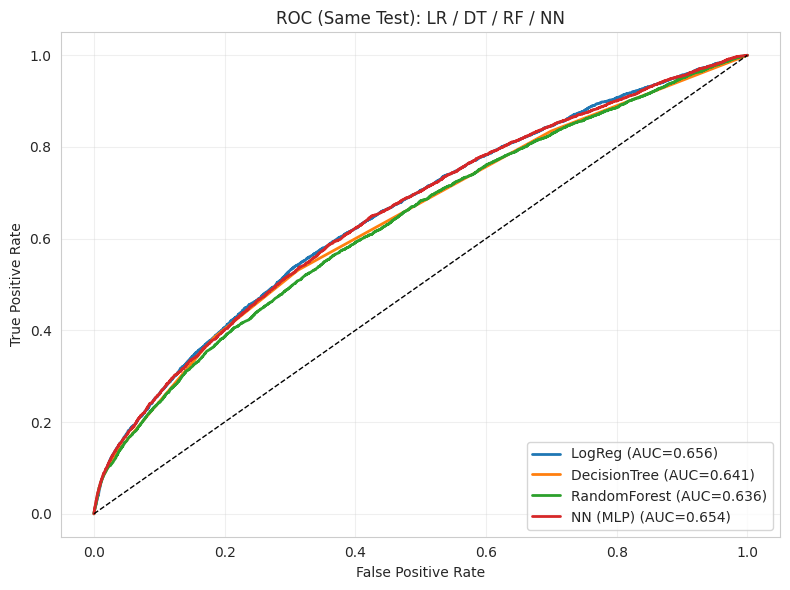

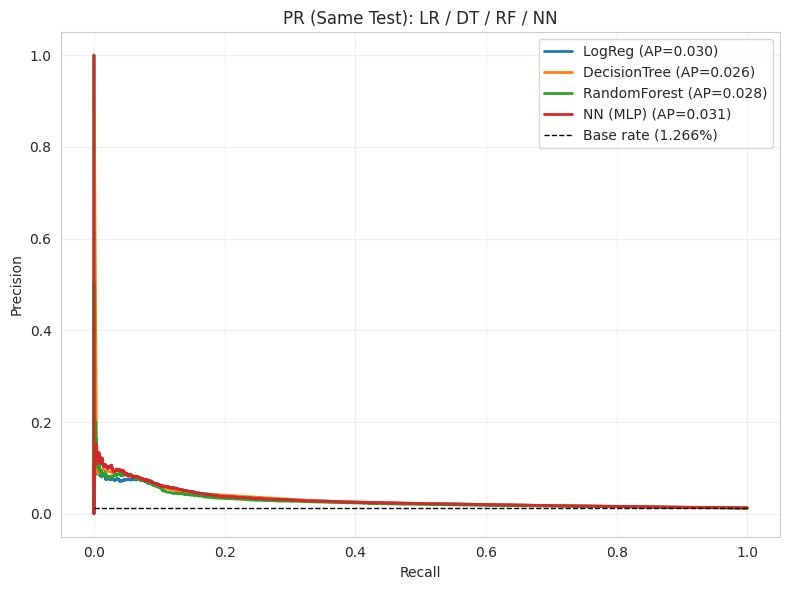


✓ Done.


In [50]:
# =========================
# ROC + PR curve plots with your EXACT variable names
#
# Baseline models (same test set):
#   y_test_baseline
#   LR: y_proba = clf.predict_proba(X_test_imp_baseline)[:, 1]
#   DT: y_proba_dt
#   RF: y_proba_rf = rf_model.predict_proba(X_test_for_rf)[:, 1]
#
# NN (may be different test set):
#   y_test (NN labels)  [you can alias y_test_nn = y_test if you want]
#   y_proba_nn_test
#
# Behavior:
#   1) Plot LR/DT/RF together on baseline test set.
#   2) Plot NN separately if its test differs.
#   3) If NN test labels happen to be identical to baseline labels, plot all 4 together.
# =========================
y_proba_nn_test = np.load("results/nn_search/y_proba_nn_test.npy")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# print("\n" + "=" * 70)
# print("PLOT: ROC + PR CURVES (LR / DT / RF) + (NN)")
# print("=" * 70)

# ---- Baseline availability checks ----
baseline_needed = ["y_test_baseline", "y_proba_lr_test", "y_proba_dt_test", "y_proba_rf_test"]
baseline_missing = [v for v in baseline_needed if v not in globals()]

# ---- NN availability checks ----
nn_needed = ["y_test", "y_proba_nn_test"]
nn_missing = [v for v in nn_needed if v not in globals()]

def plot_roc(models, title):
    plt.figure(figsize=(8, 6))
    for name, (y_true, y_score) in models.items():
        fpr, tpr, _ = roc_curve(y_true, y_score)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_pr(models, title, base_rate=None):
    plt.figure(figsize=(8, 6))
    for name, (y_true, y_score) in models.items():
        p, r, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        plt.plot(r, p, lw=2, label=f"{name} (AP={ap:.3f})")
    if base_rate is not None:
        plt.hlines(base_rate, 0, 1, colors="k", linestyles="--",
                   lw=1, label=f"Base rate ({base_rate:.3%})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# -------- 1) Baseline plots: LR/DT/RF on y_test_baseline --------
# if baseline_missing:
#     print("[Baseline] Cannot plot LR/DT/RF yet. Missing:", baseline_missing)
# else:
#     y_base = np.asarray(y_test_baseline, dtype=int)
#     baseline_models = {
#         "LogReg": (y_base, np.asarray(y_proba_lr_test, dtype=float)), # FIX: Changed y_proba to y_proba_lr_test
#         "DecisionTree": (y_base, np.asarray(y_proba_dt_test, dtype=float)), # FIX: Changed y_proba_dt to y_proba_dt_test
#         "RandomForest": (y_base, np.asarray(y_proba_rf_test, dtype=float)), # FIX: Changed y_proba_rf to y_proba_rf_test
#     }

#     print(f"[Baseline] N={len(y_base):,}, base rate={y_base.mean():.6%}")
#     plot_roc(baseline_models, "ROC (Baseline Test): LR / DT / RF")
#     plot_pr(baseline_models, "PR (Baseline Test): LR / DT / RF", base_rate=y_base.mean())

# -------- 2) NN plots (on its own y_test) --------
# if nn_missing:
#     print("\n[NN] Cannot plot NN yet. Missing:", nn_missing)
# else:
#     y_nn_true = np.asarray(y_test, dtype=int)
#     y_nn_score = np.asarray(y_proba_nn_test, dtype=float)

#     print(f"\n[NN] N={len(y_nn_true):,}, base rate={y_nn_true.mean():.6%}")
#     plot_roc({"NN (MLP)": (y_nn_true, y_nn_score)}, "ROC (NN Test)")
#     plot_pr({"NN (MLP)": (y_nn_true, y_nn_score)}, "PR (NN Test)", base_rate=y_nn_true.mean())

# -------- 3) All 4 together only if same test labels --------
if (not baseline_missing) and (not nn_missing):
    y_base = np.asarray(y_test_baseline, dtype=int)
    y_nn_true = np.asarray(y_test, dtype=int)

    same_test = (len(y_base) == len(y_nn_true)) and np.array_equal(y_base, y_nn_true)
    if same_test:
        all_models = {
            "LogReg": (y_base, np.asarray(y_proba_lr_test, dtype=float)), # FIX: Changed y_proba to y_proba_lr_test
            "DecisionTree": (y_base, np.asarray(y_proba_dt_test, dtype=float)), # FIX: Changed y_proba_dt to y_proba_dt_test
            "RandomForest": (y_base, np.asarray(y_proba_rf_test, dtype=float)), # FIX: Changed y_proba_rf to y_proba_rf_test
            "NN (MLP)": (y_base, np.asarray(y_proba_nn_test, dtype=float)),
        }
        print("\n[All models] Same test labels detected -> plotting all 4 together.")
        plot_roc(all_models, "ROC (Same Test): LR / DT / RF / NN")
        plot_pr(all_models, "PR (Same Test): LR / DT / RF / NN", base_rate=y_base.mean())
    else:
        print("\n[All models] NN test labels differ from baseline -> not plotting all 4 on one figure (fairness).")

print("\n✓ Done.")


In [51]:
# =========================
# Logistic Regression: Top-K Targeting Evaluation (baseline test set)
# Uses:
#   y_test_baseline  (labels)
#   y_proba          (LR predict_proba[:,1] on baseline test set)
# Outputs:
#   topk_lr_df, cms_lr
# =========================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION: TOP-K TARGETING (0.5% / 1% / 2%) ON BASELINE TEST")
print("=" * 70)

assert "y_test_baseline" in globals(), "y_test_baseline not found."
assert "y_proba_lr_test" in globals(), "y_proba_lr_test (LR probabilities) not found." # FIX: Changed to y_proba_lr_test

y_true = np.asarray(y_test_baseline, dtype=int)
y_score = np.asarray(y_proba_lr_test, dtype=float) # FIX: Changed to y_proba_lr_test

assert len(y_true) == len(y_score), "y_test_baseline and y_proba must have same length."
assert set(np.unique(y_true)).issubset({0, 1}), "labels must be binary {0,1}."

n = len(y_true)
base_rate = y_true.mean()
print(f"Test size: {n:,}")
print(f"Base rate (P(y=1) on test): {base_rate:.6%}")

def topk_metrics(y_true, y_score, top_frac):
    n = len(y_true)
    k = max(int(np.ceil(n * top_frac)), 1)

    idx_sorted = np.argsort(-y_score)      # descending by score
    idx_topk = idx_sorted[:k]
    thr = float(y_score[idx_topk[-1]])     # cutoff score at rank k

    y_pred = np.zeros(n, dtype=int)
    y_pred[idx_topk] = 1

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision_k = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_k = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    lift_k = (precision_k / base_rate) if base_rate > 0 else np.nan

    return {
        "top_frac": float(top_frac),
        "k": int(k),
        "threshold_at_k": float(thr),
        "precision_at_k": float(precision_k),
        "recall_at_k": float(recall_k),
        "lift_at_k": float(lift_k),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }, np.array([[tn, fp], [fn, tp]])

top_fracs = [0.005, 0.01, 0.02]  # 0.5%, 1%, 2%
rows = []
cms_lr = {}

for f in top_fracs:
    m, cm = topk_metrics(y_true, y_score, f)
    rows.append(m)
    cms_lr[f] = cm

topk_lr_df = pd.DataFrame(rows)
topk_lr_df["top_pct"] = (topk_lr_df["top_frac"] * 100).map(lambda x: f"{x:.1f}%")
topk_lr_df = topk_lr_df[[
    "top_pct", "k", "threshold_at_k",
    "precision_at_k", "recall_at_k", "lift_at_k",
    "tp", "fp", "fn", "tn"
]]

print("\nTop-K Summary (LogReg):")
display(topk_lr_df)

print("\nConfusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):")
for f in top_fracs:
    print(f"\n--- Top {f*100:.1f}% (k={int(np.ceil(n*f)):,}) ---")
    print(cms_lr[f])

print("\n✓ Saved: topk_lr_df, cms_lr")



LOGISTIC REGRESSION: TOP-K TARGETING (0.5% / 1% / 2%) ON BASELINE TEST
Test size: 353,618
Base rate (P(y=1) on test): 1.266338%

Top-K Summary (LogReg):


,top_pct,k,threshold_at_k,precision_at_k,recall_at_k,lift_at_k,tp,fp,fn,tn
0,0.5%,1769,0.891258,0.075184,0.029701,5.937096,133,1636,4345,347504
1,1.0%,3537,0.835442,0.074640,0.058955,5.894122,264,3273,4214,345867
2,2.0%,7073,0.750724,0.062208,0.098258,4.912463,440,6633,4038,342507



Confusion Matrices by Top-K (rows=true [0,1], cols=pred [0,1]):

--- Top 0.5% (k=1,769) ---
[[347504   1636]
 [  4345    133]]

--- Top 1.0% (k=3,537) ---
[[345867   3273]
 [  4214    264]]

--- Top 2.0% (k=7,073) ---
[[342507   6633]
 [  4038    440]]

✓ Saved: topk_lr_df, cms_lr
